# DRL04 Deep Q-Learning

### Lab Description

This laboratory develops value-based deep reinforcement learning from first
principles with PyTorch. We begin with `Acrobot-v1`, where a compact
six-dimensional observation makes a **vanilla DQN** easy to inspect: an MLP
Q-network, epsilon-greedy exploration, uniform replay, a target network, and a
one-step TD target.

The second case study moves to `ALE/SpaceInvaders-v5`. Raw Atari frames are
converted into stacked grayscale observations, and the agent combines the six
canonical **Rainbow DQN** improvements: Double DQN, a dueling architecture,
prioritized replay, multi-step returns, categorical distributional learning
(C51), and NoisyNet exploration. Training uses Atari life-loss
pseudo-terminals and sign-clipped rewards, while evaluation reports complete
games with the original score.

Environment interaction and replay storage remain CPU work. Neural-network
forward passes, targets, losses, and gradients run on an AMD Radeon GPU through
PyTorch ROCm. The visual agent is feed-forward and single-process; recurrent and
distributed reinforcement learning are outside this tutorial.

Visualizations include raw Atari frames, stacked observations, learning curves,
and looping GIF rollouts after each training section and final evaluation.

#### Recommended Hardware

AMD Ryzen™ AI Halo Processors (for example, Ryzen™ AI Max+ PRO 395 or Ryzen™
AI Max 390). Both neural sections require the integrated Radeon GPU through
ROCm.

#### Software Environment

OS: Ubuntu 24.04 LTS  
Python 3.12 with Gymnasium, Arcade Learning Environment (ALE), ROCm-enabled
PyTorch, NumPy, Matplotlib, OpenCV, and ImageIO in the [AUP Learning
Cloud](https://amdresearch.github.io/aup-learning-cloud/installation/quick-start.html?family=ryzen-ai&gpu=max-pro-395) environment.

## Goals

- Derive the DQN target and distinguish termination from truncation
- Implement and evaluate a vanilla DQN on Acrobot
- Explain the purpose of each Rainbow improvement
- Derive a general n-step return and prioritized-replay correction
- Interpret C51 distributions and NoisyNet exploration
- Prepare Atari frames for a convolutional value network
- Train and checkpoint Rainbow DQN on an AMD GPU through ROCm
- Compare compact-state DQN with visual Rainbow DQN using curves and GIFs


## 1. Setup

The setup cell installs missing environment and visualization packages. ALE
0.11.2 includes the Atari ROMs used by this tutorial, so a separate ROM
downloader is unnecessary. The environments are registered explicitly before
Gymnasium creates Space Invaders.

PyTorch comes from the AUP Learning Cloud ROCm image. The notebook never
installs another PyTorch wheel because doing so could replace the AMD-compatible
build.


In [1]:
import importlib.util
import importlib.metadata
import gc
import math
import os
import site
import subprocess
import sys
import time


os.environ.setdefault("SDL_VIDEODRIVER", "dummy")

required_packages = {
    "gymnasium": "gymnasium[classic-control]",
    "ale_py": "ale-py==0.11.2",
    "pygame": "pygame",
    "imageio": "imageio",
    "cv2": "opencv-python-headless",
    "matplotlib": "matplotlib",
    "PIL": "pillow",
}
missing_packages = [
    package_name
    for module_name, package_name in required_packages.items()
    if importlib.util.find_spec(module_name) is None
]

def installed_distribution_version(distribution_name):
    try:
        return importlib.metadata.version(distribution_name)
    except importlib.metadata.PackageNotFoundError:
        return None


if installed_distribution_version("ale-py") != "0.11.2":
    missing_packages.append("ale-py==0.11.2")
missing_packages = list(dict.fromkeys(missing_packages))

if missing_packages:
    print("Installing missing packages:", ", ".join(missing_packages))
    subprocess.check_call(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "--user",
            "--quiet",
            "--no-warn-script-location",
            *missing_packages,
        ]
    )
    site.addsitedir(site.getusersitepackages())

if importlib.util.find_spec("torch") is None:
    raise RuntimeError(
        "PyTorch is missing. Start this notebook with the AUP Learning "
        "Cloud ROCm image instead of installing a generic PyTorch wheel."
    )

import copy
import random
from collections import deque
from dataclasses import asdict, dataclass, replace
from importlib.metadata import version as package_version
from pathlib import Path

import ale_py
import cv2
import gymnasium as gym
import imageio.v2 as imageio
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from IPython.display import Image, display
from PIL import Image as PILImage
from torch.nn.utils import clip_grad_norm_

gym.register_envs(ale_py)

torch.set_num_threads(min(4, os.cpu_count() or 1))

print("Python:", sys.version.split()[0])
print("Gymnasium:", gym.__version__)
print("ALE:", package_version("ale-py"))
print("PyTorch:", torch.__version__)
print("ROCm/HIP:", torch.version.hip or "not available")
print("NumPy:", np.__version__)
print("Matplotlib:", matplotlib.__version__)
print("OpenCV:", cv2.__version__)
assert package_version("ale-py") == "0.11.2"


Python: 3.12.3
Gymnasium: 1.3.0
ALE: 0.11.2
PyTorch: 2.9.1+rocm7.13.0
ROCm/HIP: 7.13.99004-3309c6114a
NumPy: 2.4.6
Matplotlib: 3.11.0
OpenCV: 5.0.0


In [2]:
SEED = 17
ACROBOT_ENV_NAME = "Acrobot-v1"
SPACE_INVADERS_ENV_NAME = "ALE/SpaceInvaders-v5"
SPACE_INVADERS_ACTIONS = (
    "NOOP",
    "FIRE",
    "RIGHT",
    "LEFT",
    "RIGHTFIRE",
    "LEFTFIRE",
)
ATARI_BASE_FRAME_SKIP = 1
ATARI_NOOP_MAX = 30
ATARI_REPEAT_ACTION_PROBABILITY = 0.0
ATARI_FULL_ACTION_SPACE = False
ATARI_TERMINAL_ON_LIFE_LOSS = True
ATARI_CLIP_REWARD = True
ATARI_EVALUATION_TERMINAL_ON_LIFE_LOSS = False
ATARI_EVALUATION_CLIP_REWARD = False
ARTIFACT_DIR = Path("artifacts") / "DRL04"
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

ROCM_AVAILABLE = bool(
    torch.cuda.is_available() and torch.version.hip is not None
)
if not ROCM_AVAILABLE:
    raise RuntimeError(
        "DRL04 requires the AUP Learning Cloud ROCm image and a visible "
        "AMD GPU. CPU and NVIDIA CUDA fallbacks are disabled."
    )

ROCM_DEVICE = torch.device("cuda:0")
torch.cuda.set_device(ROCM_DEVICE)
GPU_NAME = torch.cuda.get_device_name(ROCM_DEVICE)
GPU_PROPERTIES = torch.cuda.get_device_properties(ROCM_DEVICE)


def seed_everything(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


def model_device(model):
    return next(model.parameters()).device


def require_amd_gpu(device=None, model=None):
    if not ROCM_AVAILABLE:
        raise RuntimeError("A visible AMD ROCm GPU is required.")
    resolved = ROCM_DEVICE if device is None else torch.device(device)
    if resolved.type != "cuda" or torch.version.hip is None:
        raise RuntimeError(
            "Neural computation must use PyTorch ROCm on cuda:0; "
            f"received device={resolved}."
        )
    if model is not None and model_device(model) != resolved:
        raise RuntimeError(
            f"Model is on {model_device(model)}, expected {resolved}."
        )
    return resolved


def moving_average(values, window=50):
    values = np.asarray(values, dtype=np.float64)
    if values.size == 0:
        return np.asarray([]), np.asarray([])
    if values.size < window:
        return np.arange(values.size), values
    kernel = np.ones(window, dtype=np.float64) / window
    smooth = np.convolve(values, kernel, mode="valid")
    return np.arange(window - 1, values.size), smooth


# Prefer deterministic convolution algorithms when available.
torch.backends.cudnn.deterministic = True
seed_everything()
require_amd_gpu()
torch.cuda.synchronize()
probe = torch.randn(
    512,
    512,
    device=ROCM_DEVICE,
    requires_grad=True,
)
probe_value = (probe @ probe).square().mean()
probe_value.backward()
torch.cuda.synchronize()
assert (
    probe.is_cuda
    and probe_value.is_cuda
    and probe.grad is not None
    and probe.grad.is_cuda
)
del probe, probe_value

print("Neural device:", ROCM_DEVICE)
print("Accelerator backend: ROCm/HIP")
print("AMD GPU:", GPU_NAME)
print(f"Visible GPU memory: {GPU_PROPERTIES.total_memory / 2**30:.1f} GiB")
print("ROCm matrix-operation probe: passed")
print("Artifacts:", ARTIFACT_DIR.resolve())


Neural device: cuda:0
Accelerator backend: ROCm/HIP
AMD GPU: Radeon 8060S Graphics
Visible GPU memory: 64.0 GiB
ROCm matrix-operation probe: passed


Artifacts: /home/jovyan/work/artifacts/DRL04


## 2. Understanding the Acrobot Environment

Acrobot is a two-link underactuated robot. The first joint is fixed to a
support, and the agent applies torque only at the joint between the links.
The objective is to swing the free end above a target height.

### Observation Space

| Index | Variable | Meaning | Approximate range |
|---:|---|---|---|
| 0 | $\cos(\theta_1)$ | Cosine of link 1 angle | $[-1,1]$ |
| 1 | $\sin(\theta_1)$ | Sine of link 1 angle | $[-1,1]$ |
| 2 | $\cos(\theta_2)$ | Cosine of link 2 angle | $[-1,1]$ |
| 3 | $\sin(\theta_2)$ | Sine of link 2 angle | $[-1,1]$ |
| 4 | $\dot\theta_1$ | Angular velocity of link 1 | $[-4\pi,4\pi]$ |
| 5 | $\dot\theta_2$ | Angular velocity of link 2 | $[-9\pi,9\pi]$ |

### Actions and Reward

| Action | Applied torque |
|---:|---:|
| 0 | $-1$ |
| 1 | $0$ |
| 2 | $+1$ |

The environment returns $-1$ before every successful terminal transition,
so a return closer to zero means a faster swing-up. `terminated=True` means
the physical goal was reached; `truncated=True` means the 500-step wrapper
limit ended the rollout.


Environment: Acrobot-v1
Observation space: Box([ -1.        -1.        -1.        -1.       -12.566371 -28.274334], [ 1.        1.        1.        1.       12.566371 28.274334], (6,), float32)
Action space: Discrete(3)
Maximum steps: 500
Sample observation: [ 0.998  0.069  0.998 -0.068  0.012 -0.026]


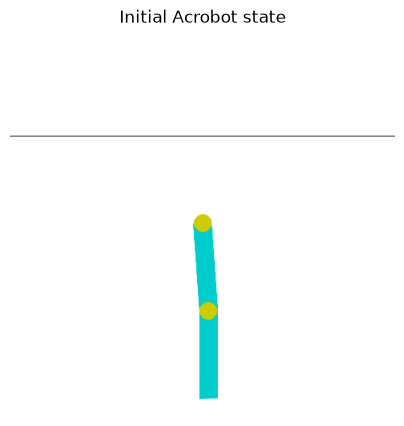

In [3]:
acrobot_preview = gym.make(
    ACROBOT_ENV_NAME,
    render_mode="rgb_array",
)
acrobot_observation, acrobot_info = acrobot_preview.reset(seed=SEED)

print("Environment:", ACROBOT_ENV_NAME)
print("Observation space:", acrobot_preview.observation_space)
print("Action space:", acrobot_preview.action_space)
print("Maximum steps:", acrobot_preview.spec.max_episode_steps)
print("Sample observation:", np.round(acrobot_observation, 3))

plt.figure(figsize=(5, 5))
plt.imshow(acrobot_preview.render())
plt.axis("off")
plt.title("Initial Acrobot state")
plt.show()
acrobot_preview.close()


## 3. Random-Agent Baseline

A seeded random policy checks the complete environment, termination, and
rendering path before learning begins. A random Acrobot policy commonly
reaches the 500-step limit, giving a return near $-500$.


Random policy | return: -500 | steps: 500


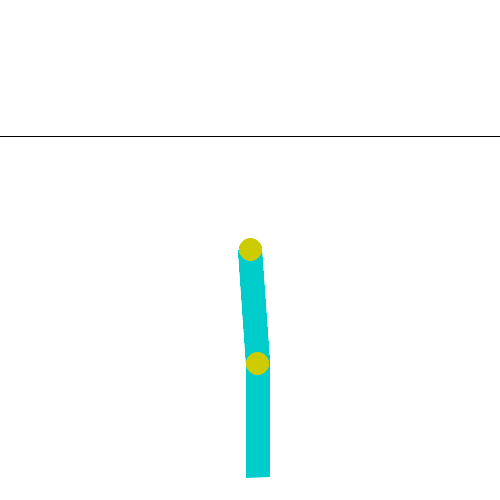

In [4]:
def random_acrobot_rollout(
    seed=SEED,
    filename="acrobot_random.gif",
    capture_every=2,
):
    env = gym.make(ACROBOT_ENV_NAME, render_mode="rgb_array")
    env.action_space.seed(seed)
    state, _ = env.reset(seed=seed)
    frames = [env.render().copy()]
    total_reward = 0.0
    terminated = truncated = False
    steps = 0

    while not (terminated or truncated):
        action = env.action_space.sample()
        state, reward, terminated, truncated, _ = env.step(action)
        total_reward += float(reward)
        steps += 1
        if steps % capture_every == 0 or terminated or truncated:
            frames.append(env.render().copy())

    env.close()
    path = ARTIFACT_DIR / filename
    imageio.mimsave(path, frames, fps=30, loop=0)
    return path, total_reward, steps


random_acrobot_gif, random_acrobot_return, random_acrobot_steps = (
    random_acrobot_rollout()
)
print(
    f"Random policy | return: {random_acrobot_return:.0f} "
    f"| steps: {random_acrobot_steps}"
)
display(Image(filename=str(random_acrobot_gif)))


## 4. From Tabular Q-Learning to DQN

DQN replaces the Q-table from DRL01 with a neural network
$Q_\theta(s,a)$. For a sampled one-step transition, vanilla DQN uses

$$
y_t=r_t+\gamma(1-\text{terminated}_t)
\max_{a'}Q_{\bar\theta}(s_{t+1},a'),
$$

where $\bar\theta$ is a periodically copied target network. The online
network minimizes the Huber loss

$$
\mathcal L(\theta)=
\mathbb E\left[
  \operatorname{Huber}\left(Q_\theta(s_t,a_t)-y_t\right)
\right].
$$

The behavior policy is epsilon-greedy. With probability $\epsilon$ it
chooses a random action; otherwise it chooses the largest predicted
Q-value.

Two Boolean concepts must remain separate:

$$
e_t=\text{terminated}_t\lor\text{truncated}_t,\qquad
m_t=1-\text{terminated}_t.
$$

$e_t$ tells the interaction loop to reset. For Acrobot, the bootstrap mask
$m_t$ becomes zero only at true task termination. An external time limit ends
data collection but does not pretend that the underlying state has no future
value. The Atari section later introduces life loss as an additional terminal
boundary used only by the learner.


## 5. Building a Vanilla DQN Agent

Acrobot already supplies a compact feature vector, so a two-hidden-layer
MLP is sufficient. This first agent deliberately uses none of the Rainbow
extensions introduced later.

The bounded uniform transition store exists only during training. It holds
recent $(s,a,r,s',\text{terminated})$ tuples and samples them without
prioritization. Evaluation performs no replay storage or parameter updates.


In [5]:
class AcrobotQNetwork(nn.Module):
    """MLP that predicts one action value for each Acrobot torque."""

    def __init__(self, obs_dim, action_dim, hidden_dim=128):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(obs_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, action_dim),
        )

    def forward(self, states):
        return self.layers(states)


class UniformTransitionStore:
    """Finite, uniformly sampled training transitions."""

    def __init__(self, capacity, seed=SEED):
        self.data = deque(maxlen=int(capacity))
        self.rng = np.random.default_rng(seed)

    def add(self, state, action, reward, next_state, terminated):
        self.data.append(
            (
                np.asarray(state, dtype=np.float32).copy(),
                int(action),
                float(reward),
                np.asarray(next_state, dtype=np.float32).copy(),
                bool(terminated),
            )
        )

    def sample(self, batch_size):
        indices = self.rng.choice(
            len(self.data),
            size=int(batch_size),
            replace=False,
        )
        batch = [self.data[int(index)] for index in indices]
        states, actions, rewards, next_states, terminated = zip(*batch)
        return (
            np.asarray(states, dtype=np.float32),
            np.asarray(actions, dtype=np.int64),
            np.asarray(rewards, dtype=np.float32),
            np.asarray(next_states, dtype=np.float32),
            np.asarray(terminated, dtype=np.float32),
        )

    def __len__(self):
        return len(self.data)

    def clear(self):
        self.data.clear()


acrobot_network_probe = AcrobotQNetwork(6, 3).to(ROCM_DEVICE)
require_amd_gpu(model=acrobot_network_probe)
acrobot_batch_probe = torch.zeros(4, 6, device=ROCM_DEVICE)
acrobot_q_probe = acrobot_network_probe(acrobot_batch_probe)
assert acrobot_q_probe.shape == (4, 3) and acrobot_q_probe.is_cuda
print("Acrobot input batch:", tuple(acrobot_batch_probe.shape))
print("Acrobot Q-value batch:", tuple(acrobot_q_probe.shape))
print("Network device:", model_device(acrobot_network_probe))
del acrobot_network_probe, acrobot_batch_probe, acrobot_q_probe


Acrobot input batch: (4, 6)
Acrobot Q-value batch: (4, 3)
Network device: cuda:0


### 5.1 Configuration and Update

The training loop first collects a small set of transitions, then performs
one gradient update per environment decision. Epsilon decays linearly with
decisions. Every fixed number of learner updates, the target parameters are
replaced by an exact copy:

$$
\bar\theta\leftarrow\theta.
$$

All sampled arrays are converted directly into tensors on `cuda:0`. The
update asserts that the model, predictions, target, and loss remain on the
ROCm device.


In [6]:
@dataclass(frozen=True)
class AcrobotDQNConfig:
    env_name: str = ACROBOT_ENV_NAME
    hidden_dim: int = 128
    gamma: float = 0.99
    learning_rate: float = 1e-3
    replay_capacity: int = 20_000
    learning_starts: int = 1_000
    batch_size: int = 128
    target_update_interval: int = 500
    max_grad_norm: float = 10.0
    epsilon_start: float = 1.0
    epsilon_end: float = 0.05
    epsilon_decay_steps: int = 40_000
    episodes: int = 450


class AcrobotDQNAgent:
    def __init__(self, obs_dim, action_dim, config, seed=SEED):
        self.config = config
        self.action_dim = int(action_dim)
        self.rng = np.random.default_rng(seed)
        self.online = AcrobotQNetwork(
            obs_dim,
            action_dim,
            config.hidden_dim,
        ).to(ROCM_DEVICE)
        self.target = copy.deepcopy(self.online).to(ROCM_DEVICE)
        self.target.eval()
        for parameter in self.target.parameters():
            parameter.requires_grad_(False)
        self.optimizer = torch.optim.Adam(
            self.online.parameters(),
            lr=config.learning_rate,
        )
        self.transitions = UniformTransitionStore(
            config.replay_capacity,
            seed=seed + 1,
        )
        self.update_steps = 0
        require_amd_gpu(model=self.online)

    def epsilon(self, environment_step):
        fraction = min(
            1.0,
            float(environment_step) / self.config.epsilon_decay_steps,
        )
        return self.config.epsilon_start + fraction * (
            self.config.epsilon_end - self.config.epsilon_start
        )

    def act(self, state, epsilon=0.0):
        if self.rng.random() < epsilon:
            return int(self.rng.integers(self.action_dim))
        state_tensor = torch.as_tensor(
            state,
            dtype=torch.float32,
            device=ROCM_DEVICE,
        ).unsqueeze(0)
        with torch.inference_mode():
            q_values = self.online(state_tensor)
        assert q_values.is_cuda
        return int(q_values.argmax(dim=1).item())

    def learn(self):
        cfg = self.config
        if len(self.transitions) < max(
            cfg.learning_starts,
            cfg.batch_size,
        ):
            return None

        arrays = self.transitions.sample(cfg.batch_size)
        states = torch.as_tensor(
            arrays[0],
            dtype=torch.float32,
            device=ROCM_DEVICE,
        )
        actions = torch.as_tensor(
            arrays[1],
            dtype=torch.long,
            device=ROCM_DEVICE,
        )
        rewards = torch.as_tensor(
            arrays[2],
            dtype=torch.float32,
            device=ROCM_DEVICE,
        )
        next_states = torch.as_tensor(
            arrays[3],
            dtype=torch.float32,
            device=ROCM_DEVICE,
        )
        terminated = torch.as_tensor(
            arrays[4],
            dtype=torch.float32,
            device=ROCM_DEVICE,
        )
        assert all(
            tensor.is_cuda
            for tensor in (
                states,
                actions,
                rewards,
                next_states,
                terminated,
            )
        )

        predicted_q = self.online(states).gather(
            1,
            actions.unsqueeze(1),
        ).squeeze(1)
        with torch.no_grad():
            next_q = self.target(next_states).max(dim=1).values
            target_q = (
                rewards
                + cfg.gamma * (1.0 - terminated) * next_q
            )

        loss = F.smooth_l1_loss(predicted_q, target_q)
        assert predicted_q.is_cuda and target_q.is_cuda and loss.is_cuda
        self.optimizer.zero_grad(set_to_none=True)
        loss.backward()
        clip_grad_norm_(self.online.parameters(), cfg.max_grad_norm)
        self.optimizer.step()

        self.update_steps += 1
        if self.update_steps % cfg.target_update_interval == 0:
            self.target.load_state_dict(self.online.state_dict())
        return float(loss.detach().item())


## 6. Training and Evaluating DQN on Acrobot

Training returns include exploratory actions. Greedy evaluation is a
separate no-update path using a disjoint seed range. We report return,
episode length, and the fraction of rollouts that reach true termination.
A GIF uses the evaluation seed closest to the median return rather than a
hand-picked best episode.


In [7]:
@dataclass
class AcrobotTrainingHistory:
    returns: list
    lengths: list
    epsilons: list
    losses: list
    loss_steps: list


def train_acrobot_dqn(config, seed=SEED):
    require_amd_gpu()
    seed_everything(seed)
    env = gym.make(config.env_name)
    env.action_space.seed(seed)
    obs_dim = int(np.prod(env.observation_space.shape))
    action_dim = int(env.action_space.n)
    agent = AcrobotDQNAgent(
        obs_dim,
        action_dim,
        config,
        seed=seed,
    )
    history = AcrobotTrainingHistory([], [], [], [], [])
    environment_step = 0
    start_time = time.perf_counter()

    for episode in range(1, config.episodes + 1):
        state, _ = env.reset(seed=seed + episode)
        episode_return = 0.0
        episode_length = 0
        terminated = truncated = False

        while not (terminated or truncated):
            epsilon = agent.epsilon(environment_step)
            action = agent.act(state, epsilon=epsilon)
            next_state, reward, terminated, truncated, _ = env.step(
                action
            )
            agent.transitions.add(
                state,
                action,
                reward,
                next_state,
                terminated,
            )
            loss = agent.learn()
            if loss is not None:
                history.losses.append(loss)
                history.loss_steps.append(environment_step)

            state = next_state
            episode_return += float(reward)
            episode_length += 1
            environment_step += 1

        history.returns.append(episode_return)
        history.lengths.append(episode_length)
        history.epsilons.append(agent.epsilon(environment_step))

        if episode == 1 or episode % 25 == 0:
            recent = history.returns[-25:]
            print(
                f"DQN | episode {episode:3d}/{config.episodes} "
                f"| mean(25) {np.mean(recent):7.2f} "
                f"| epsilon {history.epsilons[-1]:.3f}"
            )

    env.close()
    torch.cuda.synchronize()
    elapsed = time.perf_counter() - start_time
    print(
        f"Acrobot training finished in {elapsed:.1f}s on "
        f"{GPU_NAME}."
    )
    agent.transitions.clear()
    return agent, history


def evaluate_acrobot_dqn(agent, episodes=30, seed=10_000):
    require_amd_gpu(model=agent.online)
    env = gym.make(agent.config.env_name)
    returns, lengths, successes, seeds = [], [], [], []

    for episode in range(episodes):
        episode_seed = seed + episode
        state, _ = env.reset(seed=episode_seed)
        total_reward = 0.0
        steps = 0
        terminated = truncated = False
        while not (terminated or truncated):
            action = agent.act(state, epsilon=0.0)
            state, reward, terminated, truncated, _ = env.step(action)
            total_reward += float(reward)
            steps += 1
        seeds.append(episode_seed)
        returns.append(total_reward)
        lengths.append(steps)
        successes.append(bool(terminated))

    env.close()
    return {
        "seeds": np.asarray(seeds, dtype=np.int64),
        "returns": np.asarray(returns, dtype=np.float32),
        "lengths": np.asarray(lengths, dtype=np.int32),
        "successes": np.asarray(successes, dtype=bool),
    }


def record_acrobot_dqn(agent, seed, filename="acrobot_dqn.gif"):
    require_amd_gpu(model=agent.online)
    env = gym.make(
        agent.config.env_name,
        render_mode="rgb_array",
    )
    state, _ = env.reset(seed=int(seed))
    frames = [env.render().copy()]
    total_reward = 0.0
    steps = 0
    terminated = truncated = False

    while not (terminated or truncated):
        action = agent.act(state, epsilon=0.0)
        state, reward, terminated, truncated, _ = env.step(action)
        total_reward += float(reward)
        steps += 1
        frames.append(env.render().copy())

    env.close()
    path = ARTIFACT_DIR / filename
    imageio.mimsave(path, frames, fps=30, loop=0)
    return path, total_reward, steps


In [8]:
acrobot_config = AcrobotDQNConfig()
acrobot_agent, acrobot_history = train_acrobot_dqn(acrobot_config)
acrobot_metrics = evaluate_acrobot_dqn(acrobot_agent)

print(
    "Greedy evaluation | "
    f"return {acrobot_metrics['returns'].mean():.2f} "
    f"± {acrobot_metrics['returns'].std():.2f} "
    f"| mean length {acrobot_metrics['lengths'].mean():.1f} "
    f"| success {acrobot_metrics['successes'].mean():.1%}"
)
print(
    "Last-100 training return:",
    f"{np.mean(acrobot_history.returns[-100:]):.2f}",
)


DQN | episode   1/450 | mean(25) -500.00 | epsilon 0.988


DQN | episode  25/450 | mean(25) -489.88 | epsilon 0.709


DQN | episode  50/450 | mean(25) -319.32 | epsilon 0.519


DQN | episode  75/450 | mean(25) -228.12 | epsilon 0.383


DQN | episode 100/450 | mean(25) -184.72 | epsilon 0.273


...

DQN | episode 375/450 | mean(25)  -92.28 | epsilon 0.050


DQN | episode 400/450 | mean(25) -107.04 | epsilon 0.050


DQN | episode 425/450 | mean(25)  -83.28 | epsilon 0.050


DQN | episode 450/450 | mean(25)  -84.92 | epsilon 0.050
Acrobot training finished in 71.5s on Radeon 8060S Graphics.


Greedy evaluation | return -84.70 ± 19.42 | mean length 85.7 | success 100.0%
Last-100 training return: -91.88


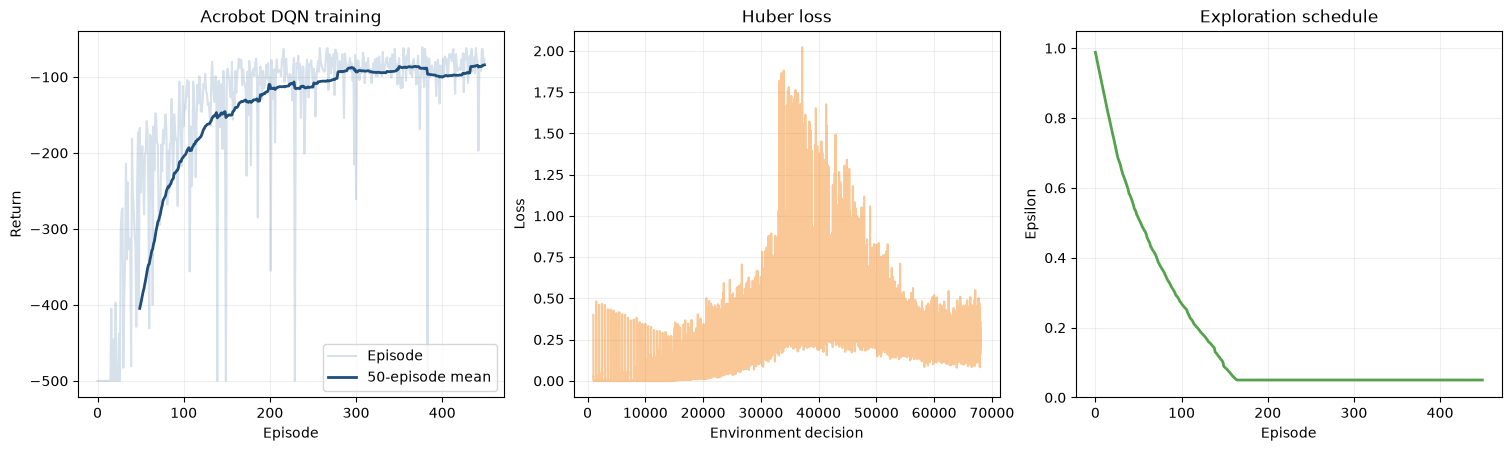

Median evaluation seed 10009 | return -82 | steps 83


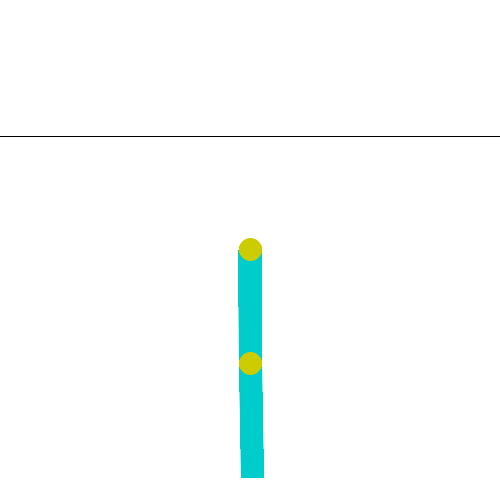

In [9]:
acrobot_x, acrobot_return_mean = moving_average(
    acrobot_history.returns,
    window=50,
)
fig, axes = plt.subplots(
    1,
    3,
    figsize=(15, 4.4),
    constrained_layout=True,
)
axes[0].plot(
    acrobot_history.returns,
    color="#4C78A8",
    alpha=0.22,
    label="Episode",
)
axes[0].plot(
    acrobot_x,
    acrobot_return_mean,
    color="#1F4E79",
    linewidth=2,
    label="50-episode mean",
)
axes[0].set(
    title="Acrobot DQN training",
    xlabel="Episode",
    ylabel="Return",
)
axes[0].legend()
axes[0].grid(alpha=0.2)

axes[1].plot(
    acrobot_history.loss_steps,
    acrobot_history.losses,
    color="#F58518",
    alpha=0.45,
)
axes[1].set(
    title="Huber loss",
    xlabel="Environment decision",
    ylabel="Loss",
)
axes[1].grid(alpha=0.2)

axes[2].plot(
    acrobot_history.epsilons,
    color="#54A24B",
    linewidth=2,
)
axes[2].set(
    title="Exploration schedule",
    xlabel="Episode",
    ylabel="Epsilon",
    ylim=(0.0, 1.05),
)
axes[2].grid(alpha=0.2)
plt.show()

median_index = int(
    np.argsort(acrobot_metrics["returns"])[
        len(acrobot_metrics["returns"]) // 2
    ]
)
median_seed = int(acrobot_metrics["seeds"][median_index])
acrobot_gif, acrobot_gif_return, acrobot_gif_steps = (
    record_acrobot_dqn(acrobot_agent, median_seed)
)
print(
    f"Median evaluation seed {median_seed} "
    f"| return {acrobot_gif_return:.0f} "
    f"| steps {acrobot_gif_steps}"
)
display(Image(filename=str(acrobot_gif)))


## 7. From DQN to Rainbow DQN

Rainbow combines six improvements that address different weaknesses of
vanilla DQN. It is a specific algorithmic combination, not simply a larger
neural network.

| Improvement | Vanilla DQN limitation | Rainbow change |
|---|---|---|
| Double DQN | The max target can overestimate values | Online network selects; target network evaluates |
| Dueling network | Some states matter more than the action distinction | Learn separate value and advantage streams |
| Prioritized replay | Uniform sampling spends equal effort on every transition | Sample informative or high-error transitions more often and correct the sampling bias |
| Multi-step returns | One-step targets propagate reward slowly | Accumulate several rewards before bootstrapping |
| C51 | A scalar Q-value hides the distribution of returns | Predict 51 categorical probabilities per action |
| NoisyNet | A hand-designed epsilon schedule is state-independent | Learn parameter noise for exploration |

These six components were introduced together in
[Rainbow: Combining Improvements in Deep Reinforcement Learning](https://arxiv.org/abs/1710.02298).
Acrobot remains the controlled vanilla baseline. Space Invaders then shows how
the six ideas work together when observations are images and rewards may be
delayed.


### 7.1 Double DQN and Dueling Networks

Double DQN separates action selection from action evaluation:

$$
a^*=\arg\max_a Q_\theta(s',a),\qquad
y=r+\gamma mQ_{\bar\theta}(s',a^*).
$$

The dueling representation separates state value from relative action
advantage:

$$
Q(s,a)=V(s)+A(s,a)
-\frac{1}{|\mathcal A|}\sum_{a'}A(s,a').
$$

Mean-centering makes the decomposition identifiable. Double DQN changes the
bootstrap target; dueling changes the representation. They solve different
problems and can be combined.


### 7.2 N-Step Returns and Prioritized Replay

A one-step target can move a distant reward backward only one transition at a
time. An n-step return carries several observed rewards into one target:

$$
R_t^{(n)} = \sum_{k=0}^{n-1} \gamma^k r_{t+k}.
$$

The corresponding distributional target is

$$
\mathcal T^{(n)}Z(s_t,a_t)
= R_t^{(n)}
+ \gamma^n(1-d_t^{(n)})Z(s_{t+n},a^\star),
$$

where $d_t^{(n)}$ indicates a terminal training transition inside the return
window. In the Atari experiment, both game over and loss of one life are
terminal for learning. If termination arrives early, the return uses the
rewards that are actually available and omits the bootstrap. The horizon $n$ is
a configurable hyperparameter; the experiment later sets $n=3$ without
changing the general definition.

Uniform replay samples every stored transition with the same probability.
Prioritized experience replay (PER) gives more sampling mass to transitions
with larger learning errors:

$$
P(i)=\frac{p_i^\alpha}{\sum_k p_k^\alpha},
\qquad
p_i=|\ell_i|+\varepsilon.
$$

Here $\ell_i$ is the categorical loss for transition $i$. Importance weights
reduce the sampling bias introduced by PER:

$$
w_i=\frac{(NP(i))^{-\beta}}
{\max_{j\in\mathcal B}(NP(j))^{-\beta}}.
$$

$\alpha$ controls how strongly priorities affect sampling, while $\beta$
controls the correction. This experiment gradually increases $\beta$ from
0.4 to 1.0 as training progresses.


### 7.3 C51 Distributional Learning and Noisy Networks

Ordinary DQN predicts one expected return per action. C51 predicts a
categorical probability mass function on fixed atoms

$$
z_i = v_{\min} + i\Delta z,
\qquad
\Delta z = \frac{v_{\max}-v_{\min}}{N_{\text{atoms}}-1}.
$$

For every target atom, the n-step Bellman transform is

$$
\widehat z_i = \operatorname{clip}\left(
R_t^{(n)}+\gamma^n(1-d_t^{(n)})z_i,
v_{\min},v_{\max}
\right).
$$

Because $\widehat z_i$ rarely lands exactly on a support atom, its probability
mass is shared between the two neighboring atoms. The projected target remains
a probability distribution, and the network learns it with categorical cross
entropy. Expected action values are recovered by weighting the atoms with their
predicted probabilities.

Atari training maps each action-repeat reward to its sign, giving rewards in
$\{-1,0,1\}$. With this bounded learning signal, the experiment uses the
conventional compact 51-atom support $[-10,10]$. This is a modeling range, not
the full theoretical discounted-return bound; targets outside it are projected
onto the endpoints. Raw game scores are retained only for reporting and
evaluation.

NoisyNet replaces an external epsilon schedule with learned parameter noise.
Each layer learns both a mean and a noise scale for its parameters:

$$
W = \mu_W + \sigma_W\odot\epsilon_W,
\qquad
b = \mu_b + \sigma_b\odot\epsilon_b,
\quad
\epsilon\sim\mathcal N(0,1).
$$

Fresh noise produces different exploratory preferences without an external
epsilon schedule. During greedy evaluation, noise is disabled and the policy
uses the learned means $\mu$.


## 8. Space Invaders as a Visual Control Problem

`ALE/SpaceInvaders-v5` presents the Atari 2600 screen as a
`(210, 160, 3)` RGB array. The player moves horizontally, fires at descending
aliens, avoids enemy shots, and receives score whenever an alien is destroyed.
Unlike Acrobot's compact state vector, a single image contains many pixels but
does not reveal motion by itself.

### Actions and Reward

The minimal action set removes joystick combinations that Space Invaders never
needs:

| Action | Meaning |
|---:|---|
| 0 | No operation |
| 1 | Fire |
| 2 | Move right |
| 3 | Move left |
| 4 | Move right and fire |
| 5 | Move left and fire |

The learner receives the sign of each action-repeat reward: positive score
increments become $+1$, zero remains $0$, and any negative increment would
become $-1$. Losing a life creates a terminal transition for learning, but it
does not restart the underlying game.

Logging and evaluation use a separate measurement view. They preserve the
original score and treat only game over as the end of a complete game. This
keeps the optimization signal bounded without changing the reported task
performance.


In [10]:
def make_raw_space_invaders_env(seed=None, render_mode=None):
    env = gym.make(
        SPACE_INVADERS_ENV_NAME,
        frameskip=ATARI_BASE_FRAME_SKIP,
        repeat_action_probability=(
            ATARI_REPEAT_ACTION_PROBABILITY
        ),
        full_action_space=ATARI_FULL_ACTION_SPACE,
        render_mode=render_mode,
    )
    env.action_space.seed(seed)
    return env


Environment: ALE/SpaceInvaders-v5
Raw observation: (210, 160, 3) uint8
Action space: Discrete(6)
Actions: {0: 'NOOP', 1: 'FIRE', 2: 'RIGHT', 3: 'LEFT', 4: 'RIGHTFIRE', 5: 'LEFTFIRE'}
Initial info keys: ['episode_frame_number', 'frame_number', 'lives', 'seeds']


A.L.E: Arcade Learning Environment (version 0.11.2+ecc1138)
[Powered by Stella]


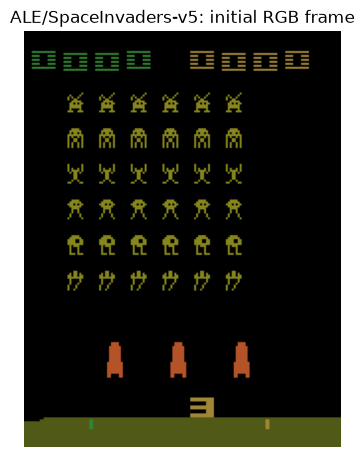

In [11]:
space_invaders_raw_preview = make_raw_space_invaders_env(
    seed=SEED,
    render_mode="rgb_array",
)
space_invaders_rgb, space_invaders_info = (
    space_invaders_raw_preview.reset(seed=SEED)
)
space_invaders_action_names = tuple(
    space_invaders_raw_preview.unwrapped.get_action_meanings()
)

assert space_invaders_rgb.shape == (210, 160, 3)
assert space_invaders_rgb.dtype == np.uint8
assert space_invaders_action_names == SPACE_INVADERS_ACTIONS
print("Environment:", SPACE_INVADERS_ENV_NAME)
print(
    "Raw observation:",
    space_invaders_rgb.shape,
    space_invaders_rgb.dtype,
)
print(
    "Action space:",
    space_invaders_raw_preview.action_space,
)
print(
    "Actions:",
    dict(enumerate(space_invaders_action_names)),
)
print("Initial info keys:", sorted(space_invaders_info))

plt.figure(figsize=(7.2, 5.4))
plt.imshow(space_invaders_rgb)
plt.axis("off")
plt.title("ALE/SpaceInvaders-v5: initial RGB frame")
plt.show()
space_invaders_raw_preview.close()


### 8.1 Atari Preprocessing

Atari agents usually learn from a compact temporal state rather than a raw RGB
frame. The training environment combines these standard transformations:

1. Reset begins with a random number of no-op actions, up to 30, so episodes do
   not all start from the same frame.
2. Each selected action is repeated for four emulator frames. Rewards across
   those frames are summed, and the last two screens are max-pooled to reduce
   flicker.
3. The pooled screen is converted to grayscale and resized to $84\times84$.
4. A life loss becomes a terminal learning transition. Reset after this
   pseudo-terminal advances the existing game with NOOP rather than restoring
   all lives.
5. The summed reward is mapped to its sign before it enters replay.
6. `FrameStackObservation(4)` combines four processed screens so the network can
   infer motion.
7. Statistics observe rewards before sign clipping and continue across
   life-loss pseudo-terminals, reporting the raw score only when the complete
   game ends.

The ALE environment itself is created with `frameskip=1`; otherwise its own
action repeat would be multiplied by the preprocessing repeat. Sticky actions
are disabled for this seeded tutorial, and the minimal six-action set is used.
The explicit episodic-life wrapper owns life-loss termination because
Gymnasium's preprocessing flag alone would restart the entire emulator after
reset. Evaluation disables both episodic life and reward clipping. Both modes
produce a `(4, 84, 84)` `uint8` state.


In [12]:
class EpisodicLifeEnv(gym.Wrapper):
    """Use each Atari life as a training episode."""

    def __init__(self, env):
        super().__init__(env)
        self.lives = 0
        self.was_real_done = True

    def step(self, action):
        observation, reward, terminated, truncated, info = (
            self.env.step(action)
        )
        self.was_real_done = bool(terminated or truncated)
        lives = int(self.env.unwrapped.ale.lives())
        if 0 < lives < self.lives:
            terminated = True
        self.lives = lives
        return observation, reward, terminated, truncated, info

    def reset(self, *, seed=None, options=None):
        if self.was_real_done:
            observation, info = self.env.reset(
                seed=seed,
                options=options,
            )
        else:
            observation, _, terminated, truncated, info = (
                self.env.step(0)
            )
            if terminated or truncated:
                observation, info = self.env.reset(
                    seed=seed,
                    options=options,
                )
                self.was_real_done = True
        self.lives = int(self.env.unwrapped.ale.lives())
        return observation, info


def clip_atari_reward(reward):
    return float(np.sign(reward))


def make_space_invaders_env(
    frame_skip=4,
    frame_stack=4,
    image_size=84,
    seed=None,
    render_mode=None,
    episodic_life=ATARI_TERMINAL_ON_LIFE_LOSS,
    clip_reward=ATARI_CLIP_REWARD,
):
    env = make_raw_space_invaders_env(
        seed=seed,
        render_mode=render_mode,
    )
    # Keep statistics inside the training-only wrappers so the
    # logged return remains the raw score for a complete game.
    env = gym.wrappers.RecordEpisodeStatistics(env)
    env = gym.wrappers.AtariPreprocessing(
        env,
        noop_max=ATARI_NOOP_MAX,
        frame_skip=int(frame_skip),
        screen_size=int(image_size),
        terminal_on_life_loss=False,
        grayscale_obs=True,
        grayscale_newaxis=False,
        scale_obs=False,
    )
    if episodic_life:
        env = EpisodicLifeEnv(env)
    if clip_reward:
        env = gym.wrappers.TransformReward(
            env,
            clip_atari_reward,
        )
    env = gym.wrappers.FrameStackObservation(
        env,
        stack_size=int(frame_stack),
    )
    env.action_space.seed(seed)
    return env


Wrapped state: (4, 84, 84) uint8
Clipped training reward: 0.0
Wrapper chain: FrameStackObservation -> TransformReward -> EpisodicLifeEnv -> AtariPreprocessing -> RecordEpisodeStatistics -> OrderEnforcing -> PassiveEnvChecker -> AtariEnv


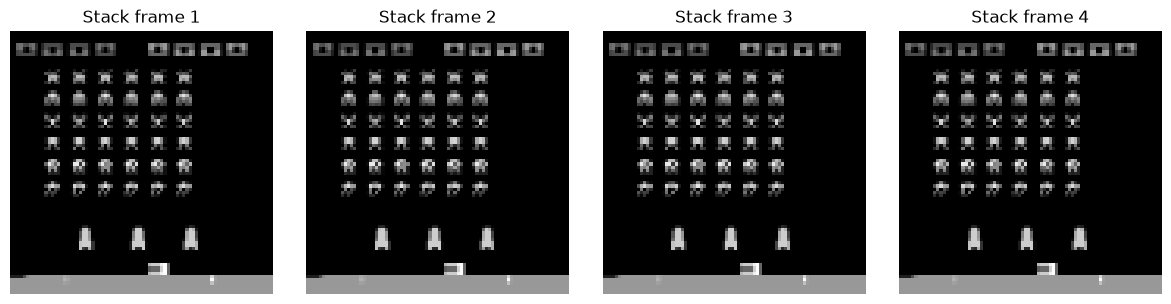

In [13]:
space_invaders_preview = make_space_invaders_env(
    seed=SEED,
    render_mode="rgb_array",
)
space_invaders_state, _ = space_invaders_preview.reset(
    seed=SEED
)
next_space_invaders_state, reward, terminated, truncated, info = (
    space_invaders_preview.step(0)
)

assert space_invaders_state.shape == (4, 84, 84)
assert space_invaders_state.dtype == np.uint8
assert next_space_invaders_state.shape == (4, 84, 84)
wrapper_names = []
wrapper = space_invaders_preview
atari_preprocessing = None
episodic_life_wrapper = None
reward_transform = None
while hasattr(wrapper, "env"):
    wrapper_names.append(type(wrapper).__name__)
    if isinstance(wrapper, gym.wrappers.AtariPreprocessing):
        atari_preprocessing = wrapper
    if isinstance(wrapper, EpisodicLifeEnv):
        episodic_life_wrapper = wrapper
    if isinstance(wrapper, gym.wrappers.TransformReward):
        reward_transform = wrapper
    wrapper = wrapper.env
wrapper_names.append(type(wrapper).__name__)
assert atari_preprocessing is not None
assert atari_preprocessing.terminal_on_life_loss is False
assert episodic_life_wrapper is not None
assert reward_transform is not None
assert reward in (-1.0, 0.0, 1.0)
print(
    "Wrapped state:",
    space_invaders_state.shape,
    space_invaders_state.dtype,
)
print("Clipped training reward:", reward)
print("Wrapper chain:", " -> ".join(wrapper_names))

fig, axes = plt.subplots(1, 4, figsize=(12, 3))
for index, axis in enumerate(axes):
    axis.imshow(
        next_space_invaders_state[index],
        cmap="gray",
    )
    axis.set_title(f"Stack frame {index + 1}")
    axis.axis("off")
plt.tight_layout()
plt.show()
space_invaders_preview.close()


## 9. Building the Rainbow Agent

A convolutional network extracts spatial features from the stacked Atari
frames. The dueling heads then estimate a state-value distribution and a
relative advantage distribution for each action. Noisy linear layers make the
action preferences exploratory during training.

C51 produces one categorical distribution per action. Its expected value is
used when an action must be selected:

$$
Q(s,a)=\sum_i z_i\,p_i(s,a).
$$

Training samples parameter noise, while evaluation disables it. A fixed
observation and model checkpoint therefore produce a deterministic greedy
action during evaluation.


In [14]:
class NoisyLinear(nn.Module):
    """Linear layer with learned independent Gaussian noise."""

    def __init__(
        self,
        in_features,
        out_features,
        sigma_init=0.5,
    ):
        super().__init__()
        self.in_features = int(in_features)
        self.out_features = int(out_features)
        self.sigma_init = float(sigma_init)

        self.weight_mu = nn.Parameter(
            torch.empty(self.out_features, self.in_features)
        )
        self.weight_sigma = nn.Parameter(
            torch.empty(self.out_features, self.in_features)
        )
        self.register_buffer(
            "weight_epsilon",
            torch.empty(self.out_features, self.in_features),
        )
        self.bias_mu = nn.Parameter(torch.empty(self.out_features))
        self.bias_sigma = nn.Parameter(torch.empty(self.out_features))
        self.register_buffer(
            "bias_epsilon",
            torch.empty(self.out_features),
        )
        self.reset_parameters()
        self.reset_noise()

    def reset_parameters(self):
        mu_range = 1.0 / math.sqrt(self.in_features)
        self.weight_mu.data.uniform_(-mu_range, mu_range)
        self.weight_sigma.data.fill_(
            self.sigma_init / math.sqrt(self.in_features)
        )
        self.bias_mu.data.uniform_(-mu_range, mu_range)
        self.bias_sigma.data.fill_(
            self.sigma_init / math.sqrt(self.out_features)
        )

    def reset_noise(self):
        self.weight_epsilon.normal_()
        self.bias_epsilon.normal_()

    def forward(self, inputs):
        if self.training:
            weight = (
                self.weight_mu
                + self.weight_sigma * self.weight_epsilon
            )
            bias = (
                self.bias_mu
                + self.bias_sigma * self.bias_epsilon
            )
        else:
            weight = self.weight_mu
            bias = self.bias_mu
        return F.linear(inputs, weight, bias)


In [15]:
class RainbowC51Network(nn.Module):
    """Noisy dueling CNN returning categorical distributions."""

    def __init__(
        self,
        state_shape,
        action_dim,
        atom_size=51,
        v_min=-10.0,
        v_max=10.0,
        sigma_init=0.5,
    ):
        super().__init__()
        channels, height, width = map(int, state_shape)
        self.action_dim = int(action_dim)
        self.atom_size = int(atom_size)
        self.v_min = float(v_min)
        self.v_max = float(v_max)
        self.delta_z = (
            self.v_max - self.v_min
        ) / (self.atom_size - 1)
        self.features = nn.Sequential(
            nn.Conv2d(channels, 32, kernel_size=8, stride=4),
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=4, stride=2),
            nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, stride=1),
            nn.ReLU(),
        )
        feature_height = height
        feature_width = width
        for kernel_size, stride in ((8, 4), (4, 2), (3, 1)):
            feature_height = (
                feature_height - kernel_size
            ) // stride + 1
            feature_width = (
                feature_width - kernel_size
            ) // stride + 1
        if feature_height <= 0 or feature_width <= 0:
            raise ValueError(
                f"State shape {state_shape} is too small for the CNN."
            )
        feature_dim = 64 * feature_height * feature_width

        self.value_head = nn.Sequential(
            NoisyLinear(
                feature_dim,
                512,
                sigma_init=sigma_init,
            ),
            nn.ReLU(),
            NoisyLinear(
                512,
                self.atom_size,
                sigma_init=sigma_init,
            ),
        )
        self.advantage_head = nn.Sequential(
            NoisyLinear(
                feature_dim,
                512,
                sigma_init=sigma_init,
            ),
            nn.ReLU(),
            NoisyLinear(
                512,
                self.action_dim * self.atom_size,
                sigma_init=sigma_init,
            ),
        )
        self.register_buffer(
            "support",
            torch.linspace(
                self.v_min,
                self.v_max,
                self.atom_size,
            ),
        )

    def forward(self, states):
        features = self.features(states.float().div(255.0))
        features = features.flatten(start_dim=1)
        value = self.value_head(features).view(
            -1,
            1,
            self.atom_size,
        )
        advantage = self.advantage_head(features).view(
            -1,
            self.action_dim,
            self.atom_size,
        )
        q_atoms = (
            value
            + advantage
            - advantage.mean(dim=1, keepdim=True)
        )
        return F.softmax(q_atoms, dim=2)

    def q_values(self, states):
        probabilities = self(states)
        return (probabilities * self.support).sum(dim=2)

    def reset_noise(self):
        for head in (self.value_head, self.advantage_head):
            for layer in head:
                if isinstance(layer, NoisyLinear):
                    layer.reset_noise()


rainbow_network_probe = RainbowC51Network(
    state_shape=(4, 84, 84),
    action_dim=len(SPACE_INVADERS_ACTIONS),
).to(ROCM_DEVICE)
require_amd_gpu(model=rainbow_network_probe)
rainbow_state_probe = torch.zeros(
    2,
    4,
    84,
    84,
    dtype=torch.uint8,
    device=ROCM_DEVICE,
)
rainbow_probability_probe = rainbow_network_probe(
    rainbow_state_probe
)
assert rainbow_probability_probe.shape == (
    2,
    len(SPACE_INVADERS_ACTIONS),
    51,
)
assert torch.allclose(
    rainbow_probability_probe.sum(dim=2),
    torch.ones(
        2,
        len(SPACE_INVADERS_ACTIONS),
        device=ROCM_DEVICE,
    ),
    atol=1e-5,
)
print(
    "Rainbow probabilities:",
    tuple(rainbow_probability_probe.shape),
)
print("Rainbow network device:", model_device(rainbow_network_probe))
del (
    rainbow_network_probe,
    rainbow_state_probe,
    rainbow_probability_probe,
)


Rainbow probabilities: (2, 6, 51)
Rainbow network device: cuda:0


MIOpen(HIP): Warning [ParseAndLoadDb] File is unreadable: "/usr/local/lib/python3.12/dist-packages/_rocm_sdk_libraries_gfx1151/share/miopen/db/gfx1151_20.HIP.fdb.txt"


### 9.1 N-Step Experience and Prioritized Sampling

The n-step accumulator converts consecutive one-step interactions into the
multi-step experience introduced above. Its horizon comes from `n_step`, so the
same replay structure can represent one-step or longer targets. At game over
or a life-loss pseudo-terminal, the remaining shorter suffixes are retained
without bootstrapping.
A truncation resets the interaction loop and clears any incomplete sequence so
rewards from different episodes are never joined.

Visual replay is much larger than vector replay. Each stored item contains a
current stacked observation, an action, an n-step reward, a next stacked
observation, and a terminal flag. Keeping the images as `uint8` avoids converting
pixels to four-byte floating point values until a mini-batch reaches the GPU.
Even in this compact form, 200,000 entries require about 10.51 GiB for the
current and next image arrays.

Priorities are updated from each transition's categorical loss. Efficient tree
sampling avoids scanning the entire replay for every mini-batch.


In [16]:
class NStepAccumulator:
    """Build transitions for a configurable n-step return."""

    def __init__(self, n_step, gamma=0.99):
        self.n_step = int(n_step)
        self.gamma = float(gamma)
        if self.n_step < 1:
            raise ValueError("n_step must be at least one.")
        self.queue = deque()

    def _build_transition(self):
        reward = 0.0
        next_state = self.queue[-1][3]
        done = self.queue[-1][4]
        for index, transition in enumerate(self.queue):
            reward += self.gamma**index * transition[2]
            next_state = transition[3]
            done = transition[4]
            if done or index + 1 == self.n_step:
                break
        return (
            self.queue[0][0],
            self.queue[0][1],
            reward,
            next_state,
            done,
        )

    def append(
        self,
        state,
        action,
        reward,
        next_state,
        done,
    ):
        self.queue.append(
            (
                state,
                int(action),
                float(reward),
                next_state,
                bool(done),
            )
        )
        emitted = []
        if len(self.queue) >= self.n_step:
            emitted.append(self._build_transition())
            self.queue.popleft()

        if done:
            while self.queue:
                emitted.append(self._build_transition())
                self.queue.popleft()
        return emitted

    def clear(self):
        self.queue.clear()

    def __len__(self):
        return len(self.queue)


In [17]:
class SumSegmentTree:
    """Array-based tree for cumulative priority mass."""

    def __init__(self, capacity):
        self.capacity = int(capacity)
        self.tree_size = 2 * self.capacity - 1
        self.tree = np.zeros(
            self.tree_size,
            dtype=np.float32,
        )

    def _propagate(self, index):
        parent = (index - 1) // 2
        while parent >= 0:
            self.tree[parent] = (
                self.tree[parent * 2 + 1]
                + self.tree[parent * 2 + 2]
            )
            parent = (parent - 1) // 2

    def update(self, index, value):
        tree_index = int(index) + self.capacity - 1
        self.tree[tree_index] = float(value)
        self._propagate(tree_index)

    def total(self):
        return float(self.tree[0])

    def retrieve(self, value):
        index = 0
        while index * 2 + 1 < self.tree_size:
            left = index * 2 + 1
            right = left + 1
            if value <= self.tree[left]:
                index = left
            else:
                value -= self.tree[left]
                index = right
        return index - (self.capacity - 1)


class MinSegmentTree:
    """Array-based tree for the minimum priority."""

    def __init__(self, capacity):
        self.capacity = int(capacity)
        self.tree_size = 2 * self.capacity - 1
        self.tree = np.full(
            self.tree_size,
            float("inf"),
            dtype=np.float32,
        )

    def _propagate(self, index):
        parent = (index - 1) // 2
        while parent >= 0:
            self.tree[parent] = min(
                self.tree[parent * 2 + 1],
                self.tree[parent * 2 + 2],
            )
            parent = (parent - 1) // 2

    def update(self, index, value):
        tree_index = int(index) + self.capacity - 1
        self.tree[tree_index] = float(value)
        self._propagate(tree_index)

    def minimum(self):
        return float(self.tree[0])


class PrioritizedTransitionStore:
    """Proportional prioritized replay for visual transitions."""

    @staticmethod
    def estimated_storage_gib(capacity, state_shape):
        capacity = int(capacity)
        observation_items = int(np.prod(state_shape))
        observation_bytes = (
            2
            * capacity
            * observation_items
            * np.dtype(np.uint8).itemsize
        )
        transition_bytes = capacity * (
            np.dtype(np.int64).itemsize
            + np.dtype(np.float32).itemsize
            + np.dtype(np.bool_).itemsize
        )
        tree_bytes = (
            2
            * (2 * capacity - 1)
            * np.dtype(np.float32).itemsize
        )
        return (
            observation_bytes
            + transition_bytes
            + tree_bytes
        ) / 2**30

    def __init__(
        self,
        capacity,
        state_shape,
        alpha=0.5,
        priority_epsilon=1e-6,
        seed=SEED,
    ):
        self.capacity = int(capacity)
        self.alpha = float(alpha)
        self.priority_epsilon = float(priority_epsilon)
        if self.capacity <= 0:
            raise ValueError("Replay capacity must be positive.")
        if self.alpha < 0.0:
            raise ValueError("PER alpha must be non-negative.")
        if self.priority_epsilon <= 0.0:
            raise ValueError("Priority epsilon must be positive.")
        self.rng = np.random.default_rng(seed)
        self.states = np.zeros(
            (self.capacity, *state_shape),
            dtype=np.uint8,
        )
        self.next_states = np.zeros_like(self.states)
        self.actions = np.zeros(
            self.capacity,
            dtype=np.int64,
        )
        self.rewards = np.zeros(
            self.capacity,
            dtype=np.float32,
        )
        self.dones = np.zeros(
            self.capacity,
            dtype=np.bool_,
        )
        self.position = 0
        self.size = 0
        self.max_priority = 1.0
        self.sum_tree = SumSegmentTree(self.capacity)
        self.min_tree = MinSegmentTree(self.capacity)

    @property
    def storage_gib(self):
        arrays = (
            self.states,
            self.next_states,
            self.actions,
            self.rewards,
            self.dones,
            self.sum_tree.tree,
            self.min_tree.tree,
        )
        return sum(array.nbytes for array in arrays) / 2**30

    def add(
        self,
        state,
        action,
        reward,
        next_state,
        done,
    ):
        index = self.position
        self.states[index] = state
        self.next_states[index] = next_state
        self.actions[index] = int(action)
        self.rewards[index] = float(reward)
        self.dones[index] = bool(done)

        priority = self.max_priority**self.alpha
        self.sum_tree.update(index, priority)
        self.min_tree.update(index, priority)
        self.position = (self.position + 1) % self.capacity
        self.size = min(self.size + 1, self.capacity)

    def sample(self, batch_size, beta):
        batch_size = int(batch_size)
        beta = float(beta)
        if self.size < batch_size:
            raise ValueError("Not enough transitions to sample.")

        indices = []
        priority_total = self.sum_tree.total()
        segment = priority_total / batch_size
        for batch_index in range(batch_size):
            low = segment * batch_index
            high = segment * (batch_index + 1)
            upper_bound = self.rng.uniform(low, high)
            indices.append(
                self.sum_tree.retrieve(upper_bound)
            )
        indices = np.asarray(indices, dtype=np.int64)

        probabilities = np.asarray(
            [
                self.sum_tree.tree[
                    index + self.capacity - 1
                ]
                for index in indices
            ],
            dtype=np.float32,
        )
        weights = (
            self.size * probabilities / priority_total
        ) ** (-beta)
        weights = weights / weights.max()

        return {
            "indices": indices,
            "states": self.states[indices],
            "actions": self.actions[indices],
            "rewards": self.rewards[indices],
            "next_states": self.next_states[indices],
            "dones": self.dones[indices],
            "weights": weights.astype(np.float32),
        }

    def update_priorities(self, indices, priorities):
        priorities = (
            np.abs(np.asarray(priorities, dtype=np.float32))
            + self.priority_epsilon
        )
        self.max_priority = max(
            self.max_priority,
            float(priorities.max()),
        )
        for index, priority in zip(indices, priorities):
            scaled_priority = float(priority) ** self.alpha
            self.sum_tree.update(index, scaled_priority)
            self.min_tree.update(index, scaled_priority)

    def release_storage(self):
        """Drop large arrays after training or an interrupted run."""
        self.states = np.empty(0, dtype=np.uint8)
        self.next_states = np.empty(0, dtype=np.uint8)
        self.actions = np.empty(0, dtype=np.int64)
        self.rewards = np.empty(0, dtype=np.float32)
        self.dones = np.empty(0, dtype=np.bool_)
        self.sum_tree = SumSegmentTree(1)
        self.min_tree = MinSegmentTree(1)
        self.position = 0
        self.size = 0

    def __len__(self):
        return self.size


### 9.2 The Rainbow Update

A Rainbow update combines the earlier ideas in one target:

1. The online network chooses the next action from expected C51 values.
2. The target network supplies that action's return distribution.
3. The n-step reward and discount shift the distribution, which is projected
   back onto the fixed C51 support.
4. Categorical cross-entropy trains the selected action distribution. PER
   importance weights scale the mini-batch losses.
5. The resulting per-transition losses become the next replay priorities.

The terminal mask includes life-loss pseudo-terminals during Atari training,
so a target never bootstraps across the boundary between two lives.

Adam performs the gradient update, and NoisyNet provides exploration without an
epsilon schedule. Learning starts after an initial collection period and then
runs every four agent decisions. The target parameters are updated with

$$
\theta^- \leftarrow
\tau\theta+(1-\tau)\theta^-.
$$

In this experiment $\tau=1$, so the target network receives a hard copy every
8,000 decisions.


In [18]:
@dataclass(frozen=True)
class RainbowConfig:
    total_steps: int = 1_000_000
    frame_skip: int = 4
    frame_stack: int = 4
    image_size: int = 84
    gamma: float = 0.99
    n_step: int = 3
    atom_size: int = 51
    v_min: float = -10.0
    v_max: float = 10.0
    sigma_init: float = 0.5
    replay_capacity: int = 200_000
    learning_starts: int = 10_000
    batch_size: int = 32
    priority_alpha: float = 0.5
    priority_beta_start: float = 0.4
    priority_epsilon: float = 1e-6
    learning_rate: float = 6.25e-5
    adam_epsilon: float = 1.5e-4
    train_frequency: int = 4
    tau: float = 1.0
    target_update_frequency: int = 8_000
    checkpoint_interval: int = 100_000
    log_interval: int = 250_000


def project_categorical_distribution(
    next_probabilities,
    rewards,
    dones,
    support,
    gamma_n,
    v_min,
    v_max,
):
    """Project a categorical Bellman target onto fixed atoms."""
    atom_size = support.numel()
    delta_z = (
        float(v_max) - float(v_min)
    ) / (atom_size - 1)
    next_atoms = (
        rewards.unsqueeze(1)
        + float(gamma_n)
        * support.unsqueeze(0)
        * (1.0 - dones.float().unsqueeze(1))
    )
    target_atoms = next_atoms.clamp(
        float(v_min),
        float(v_max),
    )
    locations = (
        target_atoms - float(v_min)
    ) / delta_z
    # The target clamp already guarantees this interval
    # mathematically. ROCm float32 division can nevertheless produce
    # an endpoint such as 50.0000038. Clamp the normalized
    # location so rounding cannot drop boundary probability mass.
    locations = locations.clamp(
        0.0,
        float(atom_size - 1),
    )
    lower = locations.floor().clamp(
        0,
        atom_size - 1,
    )
    upper = locations.ceil().clamp(
        0,
        atom_size - 1,
    )

    lower_mass = (
        upper.float()
        + (lower == locations).float()
        - locations
    ) * next_probabilities
    upper_mass = (
        locations - lower
    ) * next_probabilities
    projected = torch.zeros_like(next_probabilities)
    for batch_index in range(projected.size(0)):
        projected[batch_index].index_add_(
            0,
            lower[batch_index].long(),
            lower_mass[batch_index],
        )
        projected[batch_index].index_add_(
            0,
            upper[batch_index].long(),
            upper_mass[batch_index],
        )
    return projected


In [19]:
class RainbowAgent:
    def __init__(self, state_shape, action_dim, config, seed=SEED):
        require_amd_gpu()
        self.config = config
        self.action_dim = int(action_dim)
        self.rng = np.random.default_rng(seed)
        network_arguments = dict(
            state_shape=state_shape,
            action_dim=action_dim,
            atom_size=config.atom_size,
            v_min=config.v_min,
            v_max=config.v_max,
            sigma_init=config.sigma_init,
        )
        self.online = RainbowC51Network(
            **network_arguments
        ).to(ROCM_DEVICE)
        self.target = RainbowC51Network(
            **network_arguments
        ).to(ROCM_DEVICE)
        self.target.load_state_dict(self.online.state_dict())
        self.online.train()
        self.target.train()
        self.optimizer = torch.optim.Adam(
            self.online.parameters(),
            lr=config.learning_rate,
            eps=config.adam_epsilon,
        )
        self.update_steps = 0
        self.beta_floor = float(config.priority_beta_start)
        require_amd_gpu(model=self.online)

    def training_action(self, state):
        self.online.train()
        state_tensor = torch.as_tensor(
            state,
            dtype=torch.uint8,
            device=ROCM_DEVICE,
        ).unsqueeze(0)
        with torch.inference_mode():
            q_values = self.online.q_values(state_tensor)
        assert q_values.is_cuda
        return int(q_values.argmax(dim=1).item())

    def greedy_action(self, state):
        was_training = self.online.training
        self.online.eval()
        state_tensor = torch.as_tensor(
            state,
            dtype=torch.uint8,
            device=ROCM_DEVICE,
        ).unsqueeze(0)
        with torch.inference_mode():
            q_values = self.online.q_values(state_tensor)
        if was_training:
            self.online.train()
        assert q_values.is_cuda
        return int(q_values.argmax(dim=1).item())

    def scheduled_beta(self, environment_step, total_steps=None):
        if total_steps is None:
            total_steps = self.config.total_steps
        fraction = min(
            1.0,
            float(environment_step)
            / max(1, int(total_steps)),
        )
        return (
            self.config.priority_beta_start
            + fraction
            * (1.0 - self.config.priority_beta_start)
        )

    def beta(self, environment_step):
        return max(
            self.beta_floor,
            self.scheduled_beta(environment_step),
        )

    def learn(self, transitions, beta):
        cfg = self.config

        # Resample independent parameter noise before each update.
        self.online.train()
        self.target.train()
        self.online.reset_noise()
        self.target.reset_noise()
        batch = transitions.sample(cfg.batch_size, beta)

        states = torch.as_tensor(
            batch["states"],
            dtype=torch.uint8,
            device=ROCM_DEVICE,
        )
        actions = torch.as_tensor(
            batch["actions"],
            dtype=torch.long,
            device=ROCM_DEVICE,
        )
        rewards = torch.as_tensor(
            batch["rewards"],
            dtype=torch.float32,
            device=ROCM_DEVICE,
        )
        next_states = torch.as_tensor(
            batch["next_states"],
            dtype=torch.uint8,
            device=ROCM_DEVICE,
        )
        dones = torch.as_tensor(
            batch["dones"],
            dtype=torch.bool,
            device=ROCM_DEVICE,
        )
        weights = torch.as_tensor(
            batch["weights"],
            dtype=torch.float32,
            device=ROCM_DEVICE,
        )
        batch_indices = torch.arange(
            cfg.batch_size,
            device=ROCM_DEVICE,
        )

        with torch.no_grad():
            next_distribution = self.target(next_states)
            support = self.target.support
            next_q_values = (
                next_distribution * support
            ).sum(dim=2)

            online_next_distribution = self.online(next_states)
            online_next_q_values = (
                online_next_distribution * support
            ).sum(dim=2)
            best_actions = online_next_q_values.argmax(dim=1)
            next_probabilities = next_distribution[
                batch_indices,
                best_actions,
            ]
            target_probabilities = project_categorical_distribution(
                next_probabilities,
                rewards,
                dones,
                support,
                cfg.gamma**cfg.n_step,
                cfg.v_min,
                cfg.v_max,
            )

        distribution = self.online(states)
        predicted_distribution = distribution[
            batch_indices,
            actions,
        ]
        log_prediction = torch.log(
            predicted_distribution.clamp(
                min=1e-5,
                max=1.0 - 1e-5,
            )
        )
        per_transition_loss = -(
            target_probabilities * log_prediction
        ).sum(dim=1)
        loss = (
            per_transition_loss * weights.squeeze()
        ).mean()

        raw_priorities = (
            per_transition_loss.detach().cpu().numpy()
        )
        transitions.update_priorities(
            batch["indices"],
            raw_priorities,
        )

        q_values = (
            predicted_distribution * self.online.support
        ).sum(dim=1)
        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()
        self.update_steps += 1

        if self.update_steps == 1:
            row_sums = target_probabilities.sum(dim=1)
            if not torch.allclose(
                row_sums,
                torch.ones_like(row_sums),
                atol=1e-4,
            ):
                raise RuntimeError(
                    "C51 projection lost probability mass."
                )
            if not self.target.training:
                raise RuntimeError(
                    "Target NoisyNet must remain in training mode."
                )
            require_amd_gpu(model=self.online)
        return {
            "loss": float(loss.detach().item()),
            "mean_priority": float(
                np.mean(
                    np.abs(raw_priorities)
                    + cfg.priority_epsilon
                )
            ),
            "q_value": float(q_values.mean().detach().item()),
        }

    def sync_target(self):
        """Update target parameters using the configured tau."""
        with torch.no_grad():
            for target_parameter, online_parameter in zip(
                self.target.parameters(),
                self.online.parameters(),
            ):
                target_parameter.data.copy_(
                    self.config.tau * online_parameter.data
                    + (1.0 - self.config.tau)
                    * target_parameter.data
                )
        self.target.train()

    def algorithm_metadata(self):
        return {
            "c51_projection": "categorical_row_index_add",
            "c51_location_guard": "rocm_endpoint_clamp",
            "network_output": "categorical_probabilities",
            "loss": "per_weighted_cross_entropy",
            "priority_signal": "categorical_cross_entropy",
            "importance_sampling": "sample_batch_max",
            "noisy_parameterization": "independent_gaussian",
            "target_noisy_mode": "train_sampled",
            "n_step_done_signal": (
                "episodic_life_or_game_termination"
            ),
            "train_frequency_decisions": (
                self.config.train_frequency
            ),
            "target_sync_frequency_decisions": (
                self.config.target_update_frequency
            ),
        }

    def preprocessing_metadata(self):
        return {
            "base_frame_skip": ATARI_BASE_FRAME_SKIP,
            "frame_skip": self.config.frame_skip,
            "frame_stack": self.config.frame_stack,
            "image_size": self.config.image_size,
            "wrappers": [
                "RecordEpisodeStatistics",
                "AtariPreprocessing",
                "EpisodicLifeEnv",
                "TransformReward(sign)",
                "FrameStackObservation",
            ],
            "noop_max": ATARI_NOOP_MAX,
            "repeat_action_probability": (
                ATARI_REPEAT_ACTION_PROBABILITY
            ),
            "full_action_space": ATARI_FULL_ACTION_SPACE,
            "training_terminal_on_life_loss": (
                ATARI_TERMINAL_ON_LIFE_LOSS
            ),
            "atari_preprocessing_terminal_on_life_loss": (
                False
            ),
            "grayscale_observation": True,
            "scaled_observation": False,
            "clip_reward": ATARI_CLIP_REWARD,
            "reward_transform": (
                "sign" if ATARI_CLIP_REWARD else "none"
            ),
            "statistics_return": "raw_full_game_score",
            "evaluation_terminal_on_life_loss": (
                ATARI_EVALUATION_TERMINAL_ON_LIFE_LOSS
            ),
            "evaluation_clip_reward": (
                ATARI_EVALUATION_CLIP_REWARD
            ),
            "evaluation_reward_transform": (
                "sign"
                if ATARI_EVALUATION_CLIP_REWARD
                else "none"
            ),
        }

    def checkpoint_payload(
        self,
        environment_step,
        episode_count,
        history,
    ):
        return {
            "format": "drl04-ale-space-invaders",
            "environment_id": SPACE_INVADERS_ENV_NAME,
            "environment_step": int(environment_step),
            "episode_count": int(episode_count),
            "update_steps": int(self.update_steps),
            "config": asdict(self.config),
            "actions": SPACE_INVADERS_ACTIONS,
            "algorithm": self.algorithm_metadata(),
            "preprocessing": self.preprocessing_metadata(),
            "online_state_dict": self.online.state_dict(),
            "target_state_dict": self.target.state_dict(),
            "optimizer_state_dict": self.optimizer.state_dict(),
            "history": history,
            "numpy_rng_state": self.rng.bit_generator.state,
            "torch_rng_state": torch.get_rng_state(),
            "rocm_rng_state": torch.cuda.get_rng_state_all(),
            "beta_floor": max(
                self.beta_floor,
                self.scheduled_beta(
                    max(0, int(environment_step) - 1)
                ),
            ),
            "replay_serialized": False,
        }

    def save_checkpoint(
        self,
        path,
        environment_step,
        episode_count,
        history,
    ):
        path = Path(path)
        path.parent.mkdir(parents=True, exist_ok=True)
        temporary = path.with_suffix(path.suffix + ".tmp")
        torch.save(
            self.checkpoint_payload(
                environment_step,
                episode_count,
                history,
            ),
            temporary,
        )
        os.replace(temporary, path)

    def load_checkpoint(self, path):
        payload = torch.load(
            path,
            map_location="cpu",
            weights_only=False,
        )
        if payload.get("format") != (
            "drl04-ale-space-invaders"
        ):
            raise ValueError("Unsupported Rainbow checkpoint format.")
        if payload.get("environment_id") != (
            SPACE_INVADERS_ENV_NAME
        ):
            raise ValueError("Checkpoint environment does not match.")
        if payload.get("actions") != SPACE_INVADERS_ACTIONS:
            raise ValueError("Checkpoint action mapping does not match.")
        if payload.get("algorithm") != self.algorithm_metadata():
            raise ValueError(
                "Checkpoint Rainbow implementation does not match."
            )
        if payload.get("preprocessing") != (
            self.preprocessing_metadata()
        ):
            raise ValueError(
                "Checkpoint preprocessing metadata does not match."
            )

        current_config = asdict(self.config)
        saved_config = payload.get("config", {})
        if set(saved_config) != set(current_config):
            raise ValueError(
                "Checkpoint config schema does not match the "
                "current RainbowConfig fields."
            )
        allowed_schedule_changes = {
            "total_steps",
            "checkpoint_interval",
            "log_interval",
        }
        config_mismatches = {
            key: (saved_config.get(key), current_value)
            for key, current_value in current_config.items()
            if (
                key not in allowed_schedule_changes
                and saved_config.get(key) != current_value
            )
        }
        if config_mismatches:
            raise ValueError(
                "Checkpoint algorithm/preprocessing config does not "
                f"match the current run: {config_mismatches}"
            )
        expected_history_keys = {
            "episode",
            "step",
            "return",
            "loss_step",
            "loss",
            "mean_priority",
            "q_value",
        }
        if set(payload.get("history", {})) != expected_history_keys:
            raise ValueError(
                "Checkpoint training-history schema does not match."
            )

        saved_beta = self.scheduled_beta(
            max(0, int(payload["environment_step"]) - 1),
            total_steps=saved_config["total_steps"],
        )
        self.beta_floor = max(
            float(self.config.priority_beta_start),
            float(payload.get("beta_floor", saved_beta)),
            float(saved_beta),
        )
        self.online.load_state_dict(
            payload["online_state_dict"]
        )
        self.target.load_state_dict(
            payload["target_state_dict"]
        )
        self.online.train()
        self.target.train()
        self.optimizer.load_state_dict(
            payload["optimizer_state_dict"]
        )
        for optimizer_state in self.optimizer.state.values():
            for key, value in optimizer_state.items():
                if torch.is_tensor(value):
                    optimizer_state[key] = value.to(ROCM_DEVICE)
        self.update_steps = int(payload["update_steps"])
        self.rng.bit_generator.state = payload["numpy_rng_state"]
        torch.set_rng_state(payload["torch_rng_state"].cpu())
        torch.cuda.set_rng_state_all(
            [
                rng_state.cpu()
                for rng_state in payload["rocm_rng_state"]
            ]
        )
        require_amd_gpu(model=self.online)
        return payload


## 10. Four-Part Rainbow Training

The complete schedule is **1,000,000 agent decisions**, divided into four
cumulative cells of 250,000 decisions each. Most decisions advance four raw
emulator frames; reset no-ops add a small number of additional frames.

NoisyNet selects actions from the beginning. Optimization waits until the first
10,000 decisions have populated replay, then updates every four decisions. The
target parameters are hard-copied every 8,000 decisions.

| Setting | Value |
|---|---:|
| Environment | `ALE/SpaceInvaders-v5` |
| Action set | Minimal discrete set (6 actions) |
| Atari reset | Up to 30 random no-ops |
| Action repeat / frame stack | 4 / 4 |
| Processed observation | `(4, 84, 84)` grayscale `uint8` |
| Sticky-action probability | 0.0 |
| Training terminal on life loss | Yes, with game continuation |
| Training reward transform | Sign clipping to $\{-1,0,1\}$ |
| Reporting / evaluation | Complete-game raw score |
| Total decisions | 1,000,000 |
| Training parts | 4 × 250,000 |
| Replay capacity | 200,000 transitions |
| Replay storage | about 10.52 GiB |
| Warm-up before updates | 10,000 decisions |
| Train frequency | every 4 decisions |
| Episode console log | Every 10 complete games |
| Batch size | 32 |
| Target update | hard copy every 8,000 decisions |
| Discount / n-step | 0.99 / 3 |
| PER $\alpha$ / $\beta_0$ | 0.5 / 0.4 |
| C51 atoms / support | 51 / $[-10,10]$ |
| Optimizer | Adam, learning rate $6.25\times10^{-5}$ |

Each part writes a checkpoint and a looping greedy rollout GIF. Automatic
checkpoints are also saved every 100,000 decisions. Replay is not serialized,
so a resumed process first collects another 10,000 decisions before learning
continues.


In [20]:
def empty_atari_history():
    return {
        "episode": [],
        "step": [],
        "return": [],
        "loss_step": [],
        "loss": [],
        "mean_priority": [],
        "q_value": [],
    }


def recent_mean(values, count=20):
    if not values:
        return float("nan")
    return float(np.mean(values[-count:]))


def available_system_memory_gib():
    """Linux MemAvailable, including reclaimable page cache."""
    try:
        for line in Path("/proc/meminfo").read_text().splitlines():
            if line.startswith("MemAvailable:"):
                kibibytes = int(line.split()[1])
                return kibibytes / 2**20
    except (OSError, ValueError, IndexError):
        return None
    return None


class AtariTrainingSession:
    """Keep the environment and replay alive across four cells."""

    def __init__(
        self,
        config,
        checkpoint_path,
        seed=SEED,
        resume=True,
    ):
        require_amd_gpu()
        seed_everything(seed)
        self.config = config
        self.checkpoint_path = Path(checkpoint_path)
        self.seed = int(seed)
        self.state_shape = (
            config.frame_stack,
            config.image_size,
            config.image_size,
        )
        self.agent = RainbowAgent(
            self.state_shape,
            len(SPACE_INVADERS_ACTIONS),
            config,
            seed=seed,
        )
        self.history = empty_atari_history()
        self.environment_step = 0
        self.episode_count = 0
        self.closed = False

        if resume and self.checkpoint_path.exists():
            payload = self.agent.load_checkpoint(
                self.checkpoint_path
            )
            self.environment_step = int(
                payload["environment_step"]
            )
            self.episode_count = int(payload["episode_count"])
            self.history = payload["history"]
            print(
                f"Loaded checkpoint at "
                f"{self.environment_step:,} decisions."
            )

        # Replay is intentionally absent from checkpoints. Track the
        # first zero-based step of this process's replay so a resumed
        # run refills for learning_starts decisions before sampling.
        self.replay_origin_step = self.environment_step
        self.env = make_space_invaders_env(
            frame_skip=config.frame_skip,
            frame_stack=config.frame_stack,
            image_size=config.image_size,
            seed=seed + self.episode_count,
        )
        self.transitions = None
        self.n_step_accumulator = NStepAccumulator(
            n_step=config.n_step,
            gamma=config.gamma,
        )
        self.state, _ = self.env.reset(
            seed=seed + self.episode_count
        )
        estimated_gib = (
            PrioritizedTransitionStore.estimated_storage_gib(
                config.replay_capacity,
                self.state_shape,
            )
        )
        print(
            "Transient replay pending:",
            f"{estimated_gib:.2f} GiB CPU RAM",
        )
        print(
            "Replay is allocated by the first required training part "
            "and excluded from checkpoints."
        )

    def _ensure_replay(self):
        if self.transitions is not None:
            return

        required_gib = (
            PrioritizedTransitionStore.estimated_storage_gib(
                self.config.replay_capacity,
                self.state_shape,
            )
        )
        available_gib = available_system_memory_gib()
        reserve_gib = 4.0
        if (
            available_gib is not None
            and available_gib < required_gib + reserve_gib
        ):
            raise MemoryError(
                "The requested 200k visual replay needs "
                f"{required_gib:.2f} GiB, plus about "
                f"{reserve_gib:.1f} GiB of working headroom, but only "
                f"{available_gib:.2f} GiB is currently available. "
                "Stop Ollama and other large processes, then rerun "
                "this training cell. Replay was not allocated, so "
                "the notebook kernel remains safe."
            )

        self.transitions = PrioritizedTransitionStore(
            capacity=self.config.replay_capacity,
            state_shape=self.state_shape,
            alpha=self.config.priority_alpha,
            priority_epsilon=self.config.priority_epsilon,
            seed=self.seed + 101,
        )
        print(
            "Transient replay allocation:",
            f"{self.transitions.storage_gib:.2f} GiB CPU RAM",
        )
        if available_gib is not None:
            print(
                "System memory available before allocation:",
                f"{available_gib:.2f} GiB",
            )

    def train_until(self, target_step):
        target_step = int(target_step)
        if target_step > self.config.total_steps:
            raise ValueError("target_step exceeds total_steps.")
        if target_step <= self.environment_step:
            print(
                f"Checkpoint already reached "
                f"{self.environment_step:,}; part skipped."
            )
            return self.agent, self.history
        if self.closed:
            raise RuntimeError("Training session is already closed.")

        self._ensure_replay()
        cfg = self.config
        start_step = self.environment_step
        start_time = time.perf_counter()
        torch.cuda.reset_peak_memory_stats(ROCM_DEVICE)

        while self.environment_step < target_step:
            # NoisyNet supplies exploration from the first decision.
            action = self.agent.training_action(self.state)
            (
                next_state,
                reward,
                terminated,
                truncated,
                info,
            ) = self.env.step(action)
            self.environment_step += 1
            global_step = self.environment_step - 1
            replay_global_step = (
                global_step - self.replay_origin_step
            )

            transitions = self.n_step_accumulator.append(
                self.state,
                action,
                reward,
                next_state,
                terminated,
            )
            for transition in transitions:
                self.transitions.add(*transition)
            if truncated:
                # Do not connect n-step rewards across resets.
                self.n_step_accumulator.clear()

            if (
                replay_global_step > cfg.learning_starts
                and global_step
                % cfg.train_frequency
                == 0
            ):
                diagnostics = self.agent.learn(
                    self.transitions,
                    beta=self.agent.beta(global_step),
                )
                if global_step % 100 == 0:
                    self.history["loss_step"].append(
                        global_step
                    )
                    self.history["loss"].append(
                        diagnostics["loss"]
                    )
                    self.history["mean_priority"].append(
                        diagnostics["mean_priority"]
                    )
                    self.history["q_value"].append(
                        diagnostics["q_value"]
                    )

            if (
                replay_global_step > cfg.learning_starts
                and global_step
                % cfg.target_update_frequency
                == 0
            ):
                self.agent.sync_target()

            # Raw statistics are emitted only at real game over.
            if "episode" in info:
                episode_return = float(info["episode"]["r"])
                self.episode_count += 1
                self.history["episode"].append(self.episode_count)
                self.history["step"].append(self.environment_step)
                self.history["return"].append(episode_return)
                if self.episode_count % 10 == 0:
                    print(
                        f"Space Invaders | game "
                        f"{self.episode_count:4d} "
                        f"| decision {self.environment_step:10,d}/"
                        f"{cfg.total_steps:,} "
                        f"| raw score(20) "
                        f"{recent_mean(self.history['return']):8.1f}"
                    )

            if terminated or truncated:
                self.state, _ = self.env.reset(
                    seed=self.seed + self.episode_count
                )
            else:
                self.state = next_state

            if self.environment_step % cfg.log_interval == 0:
                elapsed = max(
                    time.perf_counter() - start_time,
                    1e-9,
                )
                rate = (
                    self.environment_step - start_step
                ) / elapsed
                print(
                    f"decision {self.environment_step:,} "
                    f"| replay {len(self.transitions):,} "
                    f"| updates {self.agent.update_steps:,} "
                    f"| beta "
                    f"{self.agent.beta(global_step):.3f} "
                    f"| {rate:.1f} decisions/s"
                )

            if (
                self.environment_step
                % cfg.checkpoint_interval
                == 0
            ):
                self.save()

        self.save()
        torch.cuda.synchronize()
        elapsed = time.perf_counter() - start_time
        peak_mib = (
            torch.cuda.max_memory_allocated(ROCM_DEVICE) / 2**20
        )
        print(
            f"Part finished: {start_step:,} → "
            f"{self.environment_step:,} decisions "
            f"in {elapsed / 3600:.2f} h "
            f"| peak GPU allocation {peak_mib:.1f} MiB"
        )
        return self.agent, self.history

    def save(self):
        self.agent.save_checkpoint(
            self.checkpoint_path,
            self.environment_step,
            self.episode_count,
            self.history,
        )
        print("Saved:", self.checkpoint_path)

    def close(self):
        if self.closed:
            return
        self.env.close()
        if self.transitions is not None:
            self.transitions.release_storage()
            self.transitions = None
        self.n_step_accumulator.clear()
        self.closed = True
        gc.collect()


In [21]:
def run_space_invaders_episode(
    agent,
    config,
    seed,
    gif_path=None,
    capture_every=8,
    max_frames=800,
):
    """Run one greedy complete-game raw-score evaluation."""
    require_amd_gpu(model=agent.online)
    env = make_space_invaders_env(
        frame_skip=config.frame_skip,
        frame_stack=config.frame_stack,
        image_size=config.image_size,
        seed=seed,
        render_mode=("rgb_array" if gif_path else None),
        episodic_life=(
            ATARI_EVALUATION_TERMINAL_ON_LIFE_LOSS
        ),
        clip_reward=ATARI_EVALUATION_CLIP_REWARD,
    )
    frames = []
    steps = 0
    episode_return = 0.0
    effective_stride = max(1, int(capture_every))

    def compact_frame():
        return cv2.resize(
            env.render(),
            (128, 168),
            interpolation=cv2.INTER_AREA,
        )

    def capture(force=False):
        nonlocal effective_stride
        if gif_path is None:
            return
        if not force and steps % effective_stride != 0:
            return
        frames.append(compact_frame())
        if len(frames) > max_frames:
            frames[:] = frames[::2]
            effective_stride *= 2

    try:
        state, _ = env.reset(seed=int(seed))
        capture(force=True)

        def take_action(action):
            nonlocal state, steps, episode_return
            (
                next_state,
                reward,
                terminated,
                truncated,
                info,
            ) = env.step(action)
            episode_return += float(reward)
            steps += 1
            capture()

            # Use the same raw complete-game metric as training logs.
            if "episode" in info:
                episode_return = float(info["episode"]["r"])

            state = next_state
            return bool(terminated or truncated)

        episode_done = False
        while not episode_done:
            episode_done = take_action(
                agent.greedy_action(state)
            )

        if gif_path is not None:
            capture(force=True)
            gif_path = Path(gif_path)
            gif_path.parent.mkdir(parents=True, exist_ok=True)
            imageio.mimsave(
                gif_path,
                frames,
                fps=15,
                loop=0,
            )
            with PILImage.open(gif_path) as gif_file:
                if gif_file.info.get("loop") != 0:
                    raise RuntimeError(
                        "GIF is not configured to loop forever."
                    )

        return {
            "seed": int(seed),
            "return": float(episode_return),
            "steps": int(steps),
            "gif_path": gif_path,
            "gif_frames": len(frames),
            "capture_every": effective_stride,
        }
    finally:
        env.close()


def segment_rollout(agent, config, completed_steps, part):
    rollout_seed = 80_000 + int(part)
    gif_path = ARTIFACT_DIR / (
        f"space_invaders_{completed_steps:08d}.gif"
    )
    result = run_space_invaders_episode(
        agent,
        config,
        seed=rollout_seed,
        gif_path=gif_path,
    )
    print(
        f"Part {part} rollout | raw game score "
        f"{result['return']:.1f} | decisions {result['steps']:,} "
        f"| seed {result['seed']} "
        f"| loops forever: True"
    )
    display(
        Image(
            data=gif_path.read_bytes(),
            format="gif",
            embed=True,
        )
    )
    return result


### 10.1 Initialize the Shared Training Session

Run this cell once before the four training parts. A new kernel can resume
the model and scalar history from the checkpoint, but it must refill the
temporary replay store.


In [22]:
if "space_invaders_training" in globals():
    # Re-running this initialization cell must release the previous
    # transient replay before a new session can ever allocate one.
    space_invaders_training.close()
    del space_invaders_training
    gc.collect()

RESUME_IF_AVAILABLE = True
SPACE_INVADERS_CHECKPOINT = (
    ARTIFACT_DIR
    / "space_invaders_checkpoint.pt"
)
space_invaders_config = RainbowConfig(total_steps=1_000_000)
space_invaders_training = AtariTrainingSession(
    space_invaders_config,
    SPACE_INVADERS_CHECKPOINT,
    seed=SEED,
    resume=RESUME_IF_AVAILABLE,
)
space_invaders_agent = space_invaders_training.agent
space_invaders_history = space_invaders_training.history
segment_rollouts = {}
print(
    "Training target:",
    f"{space_invaders_config.total_steps:,} decisions",
)
print(
    "Current decision:",
    f"{space_invaders_training.environment_step:,}",
)


Transient replay pending: 10.52 GiB CPU RAM
Replay is allocated by the first required training part and excluded from checkpoints.
Training target: 1,000,000 decisions
Current decision: 0


### 10.2 Part 1 — Decisions 0 to 250,000

This cell trains the shared session to 250,000 decisions, saves the model,
and records a looping greedy full-game rollout with the raw score.


Transient replay allocation: 10.52 GiB CPU RAM
System memory available before allocation: 34.67 GiB


Space Invaders | game   10 | decision      7,198/1,000,000 | raw score(20)    285.0


Space Invaders | game   20 | decision     12,657/1,000,000 | raw score(20)    232.2


Space Invaders | game   30 | decision     17,872/1,000,000 | raw score(20)    138.5


Space Invaders | game   40 | decision     23,469/1,000,000 | raw score(20)    120.8


...

Space Invaders | game  400 | decision    227,461/1,000,000 | raw score(20)    365.2


Space Invaders | game  410 | decision    234,281/1,000,000 | raw score(20)    350.8


Space Invaders | game  420 | decision    243,073/1,000,000 | raw score(20)    371.2


decision 250,000 | replay 200,000 | updates 59,999 | beta 0.550 | 298.0 decisions/s
Saved: artifacts/DRL04/space_invaders_checkpoint.pt
Part finished: 0 → 250,000 decisions in 0.23 h | peak GPU allocation 328.6 MiB


Part 1 rollout | raw game score 295.0 | decisions 615 | seed 80001 | loops forever: True


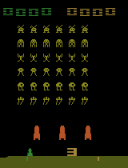

In [23]:
PART_1_TARGET = 250_000
space_invaders_agent, space_invaders_history = (
    space_invaders_training.train_until(PART_1_TARGET)
)
if space_invaders_training.environment_step == PART_1_TARGET:
    segment_rollouts[1] = segment_rollout(
        space_invaders_agent,
        space_invaders_config,
        space_invaders_training.environment_step,
        part=1,
    )
else:
    print("Part 1 rollout skipped: checkpoint is past its boundary.")


### 10.3 Part 2 — Decisions 250,000 to 500,000

This cell continues the same in-memory agent and replay to 500,000
decisions, then saves another checkpoint and raw-score evaluation GIF.


Space Invaders | game  430 | decision    251,875/1,000,000 | raw score(20)    433.2


Space Invaders | game  440 | decision    258,756/1,000,000 | raw score(20)    395.8


Space Invaders | game  450 | decision    266,130/1,000,000 | raw score(20)    350.2


Space Invaders | game  460 | decision    274,622/1,000,000 | raw score(20)    377.8


Space Invaders | game  470 | decision    282,552/1,000,000 | raw score(20)    424.0


...

Space Invaders | game  810 | decision    490,519/1,000,000 | raw score(20)    248.5


Space Invaders | game  820 | decision    496,645/1,000,000 | raw score(20)    281.5


decision 500,000 | replay 200,000 | updates 122,499 | beta 0.700 | 289.5 decisions/s
Saved: artifacts/DRL04/space_invaders_checkpoint.pt


Saved: artifacts/DRL04/space_invaders_checkpoint.pt
Part finished: 250,000 → 500,000 decisions in 0.24 h | peak GPU allocation 327.0 MiB


Part 2 rollout | raw game score 475.0 | decisions 873 | seed 80002 | loops forever: True


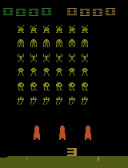

In [24]:
PART_2_TARGET = 500_000
space_invaders_agent, space_invaders_history = (
    space_invaders_training.train_until(PART_2_TARGET)
)
if space_invaders_training.environment_step == PART_2_TARGET:
    segment_rollouts[2] = segment_rollout(
        space_invaders_agent,
        space_invaders_config,
        space_invaders_training.environment_step,
        part=2,
    )
else:
    print("Part 2 rollout skipped: checkpoint is past its boundary.")


### 10.4 Part 3 — Decisions 500,000 to 750,000

This cell continues training to 750,000 decisions and emits the third
checkpointed greedy full-game evaluation.


Space Invaders | game  830 | decision    503,446/1,000,000 | raw score(20)    327.0


Space Invaders | game  840 | decision    510,483/1,000,000 | raw score(20)    335.5


Space Invaders | game  850 | decision    516,545/1,000,000 | raw score(20)    309.0


Space Invaders | game  860 | decision    523,148/1,000,000 | raw score(20)    298.5


Space Invaders | game  870 | decision    530,643/1,000,000 | raw score(20)    321.0


...

Space Invaders | game 1130 | decision    727,577/1,000,000 | raw score(20)    507.2


Space Invaders | game 1140 | decision    736,545/1,000,000 | raw score(20)    506.2


Space Invaders | game 1150 | decision    744,687/1,000,000 | raw score(20)    489.8


decision 750,000 | replay 200,000 | updates 184,999 | beta 0.850 | 292.3 decisions/s
Saved: artifacts/DRL04/space_invaders_checkpoint.pt
Part finished: 500,000 → 750,000 decisions in 0.24 h | peak GPU allocation 327.0 MiB


Part 3 rollout | raw game score 400.0 | decisions 803 | seed 80003 | loops forever: True


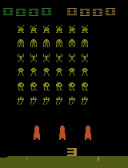

In [25]:
PART_3_TARGET = 750_000
space_invaders_agent, space_invaders_history = (
    space_invaders_training.train_until(PART_3_TARGET)
)
if space_invaders_training.environment_step == PART_3_TARGET:
    segment_rollouts[3] = segment_rollout(
        space_invaders_agent,
        space_invaders_config,
        space_invaders_training.environment_step,
        part=3,
    )
else:
    print("Part 3 rollout skipped: checkpoint is past its boundary.")


### 10.5 Part 4 — Decisions 750,000 to 1,000,000

This final training cell reaches the one-million-decision budget and writes the
fourth looping full-game Space Invaders rollout.


Space Invaders | game 1160 | decision    751,874/1,000,000 | raw score(20)    431.5


Space Invaders | game 1170 | decision    760,686/1,000,000 | raw score(20)    453.2


Space Invaders | game 1180 | decision    768,866/1,000,000 | raw score(20)    494.2


Space Invaders | game 1190 | decision    776,100/1,000,000 | raw score(20)    410.5


Space Invaders | game 1200 | decision    782,402/1,000,000 | raw score(20)    324.5


...

Space Invaders | game 1440 | decision    981,461/1,000,000 | raw score(20)    431.0


Space Invaders | game 1450 | decision    991,415/1,000,000 | raw score(20)    493.5


decision 1,000,000 | replay 200,000 | updates 247,499 | beta 1.000 | 292.6 decisions/s
Saved: artifacts/DRL04/space_invaders_checkpoint.pt


Saved: artifacts/DRL04/space_invaders_checkpoint.pt
Part finished: 750,000 → 1,000,000 decisions in 0.24 h | peak GPU allocation 327.0 MiB


Part 4 rollout | raw game score 515.0 | decisions 1,000 | seed 80004 | loops forever: True


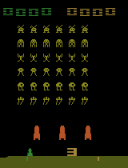

In [26]:
PART_4_TARGET = 1_000_000
space_invaders_agent, space_invaders_history = (
    space_invaders_training.train_until(PART_4_TARGET)
)
if space_invaders_training.environment_step == PART_4_TARGET:
    segment_rollouts[4] = segment_rollout(
        space_invaders_agent,
        space_invaders_config,
        space_invaders_training.environment_step,
        part=4,
    )
else:
    print("Part 4 rollout skipped: checkpoint is past its boundary.")
space_invaders_training.close()


## 11. Training Curves

The first curve plots the original Space Invaders score for every completed
game together with a 20-game moving average. Although life loss is terminal for
the learner, the inner statistics wrapper continues across lives. One plotted
point therefore represents one raw complete-game score rather than one per-life
training return.

The second curve plots the importance-weighted C51 loss. Its absolute scale is
less informative than its stability: abrupt growth can indicate unstable
targets, saturated support, or unusually concentrated replay priorities.


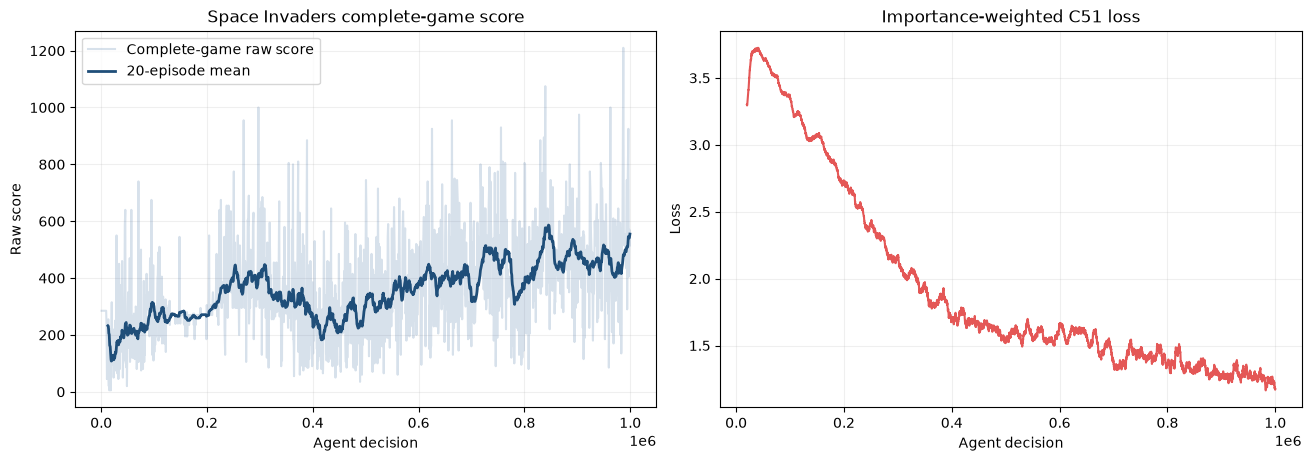

Last-20 complete-game score: 554.8


In [27]:
if not space_invaders_history["return"]:
    raise RuntimeError(
        "No completed Space Invaders episodes were recorded."
    )

returns = np.asarray(
    space_invaders_history["return"],
    dtype=np.float64,
)
return_steps = np.asarray(
    space_invaders_history["step"],
    dtype=np.int64,
)
losses = np.asarray(
    space_invaders_history["loss"],
    dtype=np.float64,
)
loss_steps = np.asarray(
    space_invaders_history["loss_step"],
    dtype=np.int64,
)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(13, 4.5),
    constrained_layout=True,
)
axes[0].plot(
    return_steps,
    returns,
    color="#4C78A8",
    alpha=0.22,
    label="Complete-game raw score",
)
if len(returns) >= 20:
    smooth_returns = np.convolve(
        returns,
        np.ones(20) / 20,
        mode="valid",
    )
    axes[0].plot(
        return_steps[19:],
        smooth_returns,
        color="#1F4E79",
        linewidth=2,
        label="20-episode mean",
    )
axes[0].set(
    title="Space Invaders complete-game score",
    xlabel="Agent decision",
    ylabel="Raw score",
)
axes[0].legend()

if len(losses) >= 100:
    smooth_losses = np.convolve(
        losses,
        np.ones(100) / 100,
        mode="valid",
    )
    axes[1].plot(
        loss_steps[99:],
        smooth_losses,
        color="#E45756",
        linewidth=1.5,
    )
else:
    axes[1].plot(loss_steps, losses, color="#E45756")
axes[1].set(
    title="Importance-weighted C51 loss",
    xlabel="Agent decision",
    ylabel="Loss",
)

for axis in axes:
    axis.grid(alpha=0.2)
plt.show()
print(
    "Last-20 complete-game score:",
    f"{recent_mean(space_invaders_history['return']):.1f}",
)


## 12. Multi-Game Evaluation and Best-Score GIF

The final checkpoint is evaluated over twenty seeded complete games without
parameter updates. Evaluation disables life-loss pseudo-terminals and reward
clipping, so each return is the original game score. NoisyNet is placed in
evaluation mode, so it uses its learned parameter means. The seeded Atari reset
makes the initial no-op sequence reproducible for each game.

We summarize the raw-score distribution and replay the highest-scoring seed
once more to create an infinitely looping GIF.


Reloaded checkpoint at 1,000,000 decisions


Evaluation game  1/20 | return    550.0 | decisions   980


Evaluation game  2/20 | return    295.0 | decisions   683


Evaluation game  3/20 | return    515.0 | decisions  1001


Evaluation game  4/20 | return   1275.0 | decisions  1802


...

Evaluation game 17/20 | return   1275.0 | decisions  1800


Evaluation game 18/20 | return    515.0 | decisions   999


Evaluation game 19/20 | return    515.0 | decisions  1006


Evaluation game 20/20 | return    515.0 | decisions  1003


Evaluation raw game score: 666.2 ± 362.5
Best episode: 4/20 | return 1275.0 | seed 90003 | decisions 1802 | loops forever: True


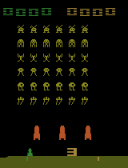

In [28]:
space_invaders_evaluation_agent = RainbowAgent(
    (
        space_invaders_config.frame_stack,
        space_invaders_config.image_size,
        space_invaders_config.image_size,
    ),
    len(SPACE_INVADERS_ACTIONS),
    space_invaders_config,
    seed=90_000,
)
space_invaders_evaluation_payload = (
    space_invaders_evaluation_agent.load_checkpoint(
        SPACE_INVADERS_CHECKPOINT
    )
)
print(
    "Reloaded checkpoint at",
    f"{space_invaders_evaluation_payload['environment_step']:,} "
    "decisions",
)

evaluation_results = []
for episode in range(20):
    episode_seed = 90_000 + episode
    result = run_space_invaders_episode(
        space_invaders_evaluation_agent,
        space_invaders_config,
        seed=episode_seed,
    )
    evaluation_results.append(result)
    print(
        f"Evaluation game {episode + 1:2d}/20 "
        f"| return {result['return']:8.1f} "
        f"| decisions {result['steps']:5d}"
    )

evaluation_returns = np.asarray(
    [result["return"] for result in evaluation_results],
    dtype=np.float64,
)
best_index = int(np.argmax(evaluation_returns))
best_result = evaluation_results[best_index]
BEST_SPACE_INVADERS_GIF = (
    ARTIFACT_DIR
    / "space_invaders.gif"
)
best_recording = run_space_invaders_episode(
    space_invaders_evaluation_agent,
    space_invaders_config,
    seed=best_result["seed"],
    gif_path=BEST_SPACE_INVADERS_GIF,
)
if not np.isclose(
    best_recording["return"],
    best_result["return"],
):
    raise RuntimeError(
        "Best rollout was not deterministic when re-recorded."
    )

print(
    f"Evaluation raw game score: "
    f"{evaluation_returns.mean():.1f} "
    f"± {evaluation_returns.std():.1f}"
)
print(
    f"Best episode: {best_index + 1}/20 "
    f"| return {best_recording['return']:.1f} "
    f"| seed {best_recording['seed']} "
    f"| decisions {best_recording['steps']} "
    f"| loops forever: True"
)
display(
    Image(
        data=BEST_SPACE_INVADERS_GIF.read_bytes(),
        format="gif",
        embed=True,
    )
)


## 13. What the Two Environments Reveal

| Question | Acrobot DQN | Space Invaders Rainbow |
|---|---|---|
| Observation | Six continuous features | Four processed image frames |
| Value network | MLP with scalar Q-values | Dueling CNN with C51 distributions |
| Exploration | Epsilon-greedy | Learned parameter noise |
| Replay | Uniform one-step transitions | Prioritized n-step transitions |
| Target | Maximum target-network Q-value | Double-DQN categorical target |
| Training reward | Original environment reward | Sign-clipped Atari reward |
| Training terminal | Goal only; time limit truncates | Game over or life-loss pseudo-terminal |
| Temporal information | Present in the state vector | Recovered by frame stacking |

The Acrobot experiment isolates the core DQN update. Space Invaders keeps that
value-learning foundation but adds the machinery needed for visual input,
delayed rewards, directed replay, and distributional targets. Evaluation is
greedy in both cases and remains separate from learning.


## Conclusions

This notebook begins with the standard DQN update on Acrobot and then extends
the same value-learning idea to visual control in Space Invaders. Rainbow does
not replace DQN's foundation; it improves action selection, representation,
credit assignment, replay sampling, return prediction, and exploration.

Atari preprocessing turns raw video into a compact temporal state. Episodic-life
terminals shorten credit-assignment boundaries, and sign rewards make a compact
$[-10,10]$ C51 support practical; out-of-range targets are projected onto its
endpoints. N-step returns and C51 provide richer training targets, prioritized
replay focuses updates on informative experience, and NoisyNet explores without
a separate epsilon schedule. The final curves and seeded GIF evaluations keep learning
behavior separate from policy assessment.


---

### References

- Mnih et al., *Human-level control through deep reinforcement learning*
- Hessel et al., *Rainbow: Combining Improvements in Deep Reinforcement
  Learning*
- Bellemare et al., *A Distributional Perspective on Reinforcement Learning*
- Machado et al., *Revisiting the Arcade Learning Environment: Evaluation
  Protocols and Open Problems for General Agents*

---

Copyright (C) 2026 Advanced Micro Devices, Inc. All rights reserved. Portions of this file consist of AI-generated content.  
SPDX-License-Identifier: MIT
